# 01 — ANOVA Factorial sobre Variables de Rendimiento PlayerMaker

## Contexto y objetivo

Este notebook aplica un **ANOVA factorial** (diseño 2×2×2×2) para cuantificar formalmente los efectos principales e interacciones de las variables de diseño táctico (**Agrupación, Espacio, Polaridad, Equilibrio**) sobre las 4 variables dependientes de rendimiento técnico-físico.

### Rol de este análisis en el TFG

El ANOVA **NO es el análisis definitivo** del proyecto. Se realiza como **paso intermedio** antes del modelo definitivo (GLMM) con tres objetivos:

1. **Demostrar competencia** en el uso del método ANOVA clásico y sus variantes.
2. **Obtener una primera cuantificación formal** de efectos principales e interacciones en un marco factorial.
3. **Documentar explícitamente las limitaciones** del ANOVA para este dataset, justificando así la necesidad del GLMM posterior.

### Variables

| Tipo | Variables |
|---|---|
| **VD** (4 análisis univariantes) | `Total Touches / min`, `Golpeos +15 m/s / min`, `Distance Covered (m) / min`, `High Intensity Distance (20 km/h) / min` |
| **VI** (factorial 2×2×2×2) | `Agrupacion`, `Espacio`, `Polaridad`, `Equilibrio` |
| **Moderadora** | `GrupoEdad` (5 niveles) |

### Estructura del notebook

| Paso | Contenido |
|---|---|
| **1** | Evaluación formal de supuestos del ANOVA |
| **2** | Decisión sobre GrupoEdad |
| **3** | ANOVA factorial clásico (Type III SS) |
| **4** | Alternativas robustas (ANOVA por permutaciones) |
| **5** | Tamaños de efecto y potencia |
| **6** | Diagnóstico y limitaciones |
| **7** | Resumen ejecutivo |

In [1]:
# ── Importaciones ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import levene, shapiro, mannwhitneyu
from itertools import combinations, product
from IPython.display import display, Markdown
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Configuración visual ────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 200,
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFA",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlepad": 12,
    "axes.labelpad": 8,
    "grid.alpha": 0.30,
    "grid.linewidth": 0.5,
    "grid.color": "#CCCCCC",
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
})

# ── Constantes del análisis ─────────────────────────────────────────────────
vd_cols = [
    "Total Touches / min",
    "Golpeos +15 m/s / min",
    "Distance Covered (m) / min",
    "High Intensity Distance (20 km/h) / min",
]
vd_labels = ["Toques / min", "Golpeos / min", "Distancia / min", "HID / min"]
vd_to_label = dict(zip(vd_cols, vd_labels))
label_to_vd = dict(zip(vd_labels, vd_cols))

vi_cols = ["Agrupacion", "Espacio", "Polaridad", "Equilibrio"]

# VD con inflación de ceros
vd_zeros = [
    "Golpeos +15 m/s / min",
    "High Intensity Distance (20 km/h) / min",
]

# Paleta de colores por VD
colores_vd = sns.color_palette("Set2", n_colors=4)
vd_to_color = dict(zip(vd_cols, colores_vd))

# Umbrales de interpretación de tamaños de efecto (eta-parcial al cuadrado)
# Cohen (1988): .01 = pequeño, .06 = medio, .14 = grande
THRESHOLDS_ETA2P = {"negligible": 0.01, "pequeño": 0.06, "medio": 0.14}

def interpretar_eta2p(eta2p):
    """Interpreta η²p según umbrales de Cohen (1988)."""
    if eta2p < 0.01:
        return "Negligible"
    elif eta2p < 0.06:
        return "Pequeño"
    elif eta2p < 0.14:
        return "Medio"
    else:
        return "Grande"

def estrellas_p(p):
    """Devuelve estrellas de significación."""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

print("✅ Importaciones y configuración completadas.")
print(f"   VD: {len(vd_cols)} variables")
print(f"   VI: {len(vi_cols)} factores (diseño 2×2×2×2 = 16 celdas)")


✅ Importaciones y configuración completadas.
   VD: 4 variables
   VI: 4 factores (diseño 2×2×2×2 = 16 celdas)


In [2]:
# ── Carga de datos ───────────────────────────────────────────────────────────
df = pd.read_excel("../Datos/Matriz_V3.xlsx")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nColumnas:\n{list(df.columns)}")
print(f"\nNulos por columna:\n{df[vd_cols + vi_cols].isnull().sum()}")
print(f"\nPrimeras filas:")
df.head(3)

Dimensiones: 4,446 filas × 19 columnas

Columnas:
['Phase Id', 'Agrupacion', 'Espacio', 'Polaridad', 'Equilibrio', 'NombreCorrecto', 'GrupoEdad', 'Phase Duration (min)', 'Player Id', 'Position Category', 'Position', 'Total Touches (#)', 'Total Touches / min', 'Golpeos +15 m/s', 'Golpeos +15 m/s / min', 'Distance Covered (m)', 'Distance Covered (m) / min', 'High Intensity Distance (20 km/h)', 'High Intensity Distance (20 km/h) / min']

Nulos por columna:
Total Touches / min                        0
Golpeos +15 m/s / min                      0
Distance Covered (m) / min                 0
High Intensity Distance (20 km/h) / min    0
Agrupacion                                 0
Espacio                                    0
Polaridad                                  0
Equilibrio                                 0
dtype: int64

Primeras filas:


,Phase Id,Agrupacion,Espacio,Polaridad,Equilibrio,NombreCorrecto,GrupoEdad,Phase Duration (min),Player Id,Position Category,Position,Total Touches (#),Total Touches / min,Golpeos +15 m/s,Golpeos +15 m/s / min,Distance Covered (m),Distance Covered (m) / min,High Intensity Distance (20 km/h),High Intensity Distance (20 km/h) / min
0,1656692,grande,reducido,Polarizado,Equilibrio,Juvenil División de Honor,Juvenil,13,111224,Midfielders,Defensive Midfielder,33,2.538462,3,0.230769,1101,84.692308,2,0.153846
1,1656692,grande,reducido,Polarizado,Equilibrio,Juvenil División de Honor,Juvenil,13,113152,Forwards,Right Winger,21,1.615385,3,0.230769,916,70.461538,6,0.461538
2,1656692,grande,reducido,Polarizado,Equilibrio,Juvenil División de Honor,Juvenil,13,113153,Defenders,Right Center Back,34,2.615385,2,0.153846,1094,84.153846,5,0.384615


---

## Paso 1 — Evaluación formal de supuestos del ANOVA

El ANOVA clásico asume:
1. **Normalidad** de los residuos del modelo.
2. **Homocedasticidad** (varianzas iguales entre grupos).
3. **Independencia** de las observaciones.

Verificamos los dos primeros formalmente; el tercero se discute cualitativamente (sabemos que está violado por medidas repetidas).

In [3]:
# ── 1.1  Ajustar modelos OLS y extraer residuos ─────────────────────────────
# Modelo factorial con efectos principales + interacciones 2-way
# (sin interacciones de 3 y 4 vías por ahora — se evaluarán en el Paso 3)

formula_2way = (
    "Q('{vd}') ~ C(Agrupacion) * C(Espacio) + C(Agrupacion) * C(Polaridad) + "
    "C(Agrupacion) * C(Equilibrio) + C(Espacio) * C(Polaridad) + "
    "C(Espacio) * C(Equilibrio) + C(Polaridad) * C(Equilibrio)"
)

residuos = {}
modelos_ols = {}
for vd in vd_cols:
    f = formula_2way.format(vd=vd)
    modelo = ols(f, data=df).fit()
    residuos[vd] = modelo.resid
    modelos_ols[vd] = modelo

print("✅ Modelos OLS ajustados y residuos extraídos para las 4 VD.")
print(f"   Fórmula: efectos principales + 6 interacciones 2-way")
print(f"   N observaciones por modelo: {modelo.nobs:.0f}")

✅ Modelos OLS ajustados y residuos extraídos para las 4 VD.
   Fórmula: efectos principales + 6 interacciones 2-way
   N observaciones por modelo: 4446


In [4]:
# ── 1.2  Test de normalidad de residuos ──────────────────────────────────────
# Con N > 5000, Shapiro-Wilk pierde sentido práctico (rechaza con cualquier
# desviación trivial). Usamos D'Agostino-Pearson que es más estable, y
# además Shapiro sobre una submuestra aleatoria de 5000 para referencia.

np.random.seed(42)
resultados_normalidad = []

for vd in vd_cols:
    res = residuos[vd].values
    n = len(res)
    asimetria = stats.skew(res)
    curtosis_exc = stats.kurtosis(res)

    # D'Agostino-Pearson (funciona bien con N grandes)
    stat_dag, p_dag = stats.normaltest(res)

    # Shapiro-Wilk sobre submuestra
    sub = np.random.choice(res, size=min(5000, n), replace=False)
    stat_sw, p_sw = stats.shapiro(sub)

    # Anderson-Darling
    ad_result = stats.anderson(res, dist="norm")
    ad_stat = ad_result.statistic
    ad_cv_5 = ad_result.critical_values[2]  # nivel 5%
    ad_rechaza = "Sí" if ad_stat > ad_cv_5 else "No"

    resultados_normalidad.append({
        "VD": vd_to_label[vd],
        "N residuos": n,
        "Asimetría": round(asimetria, 3),
        "Curtosis exc.": round(curtosis_exc, 3),
        "Shapiro W (sub)": round(stat_sw, 4),
        "p Shapiro": f"{p_sw:.2e}",
        "D'Agostino K²": round(stat_dag, 1),
        "p D'Agostino": f"{p_dag:.2e}",
        "Anderson-Darling": round(ad_stat, 2),
        "Rechaza 5%": ad_rechaza,
    })

df_norm = pd.DataFrame(resultados_normalidad)
display(Markdown("### Test de normalidad de residuos del modelo factorial"))
display(df_norm.style.set_properties(**{"text-align": "center"}))

### Test de normalidad de residuos del modelo factorial

,VD,N residuos,Asimetría,Curtosis exc.,Shapiro W (sub),p Shapiro,D'Agostino K²,p D'Agostino,Anderson-Darling,Rechaza 5%
0,Toques / min,4446,1.637000,5.248000,0.897200,1.37e-47,1551.000000,0.00e+00,94.660000,Sí
1,Golpeos / min,4446,4.543000,51.439000,0.724600,2.98e-65,4410.700000,0.00e+00,213.920000,Sí
2,Distancia / min,4446,-0.124000,0.266000,0.996700,2.27e-08,22.100000,1.60e-05,4.060000,Sí
3,HID / min,4446,4.492000,47.673000,0.720800,1.60e-65,4352.800000,0.00e+00,255.180000,Sí


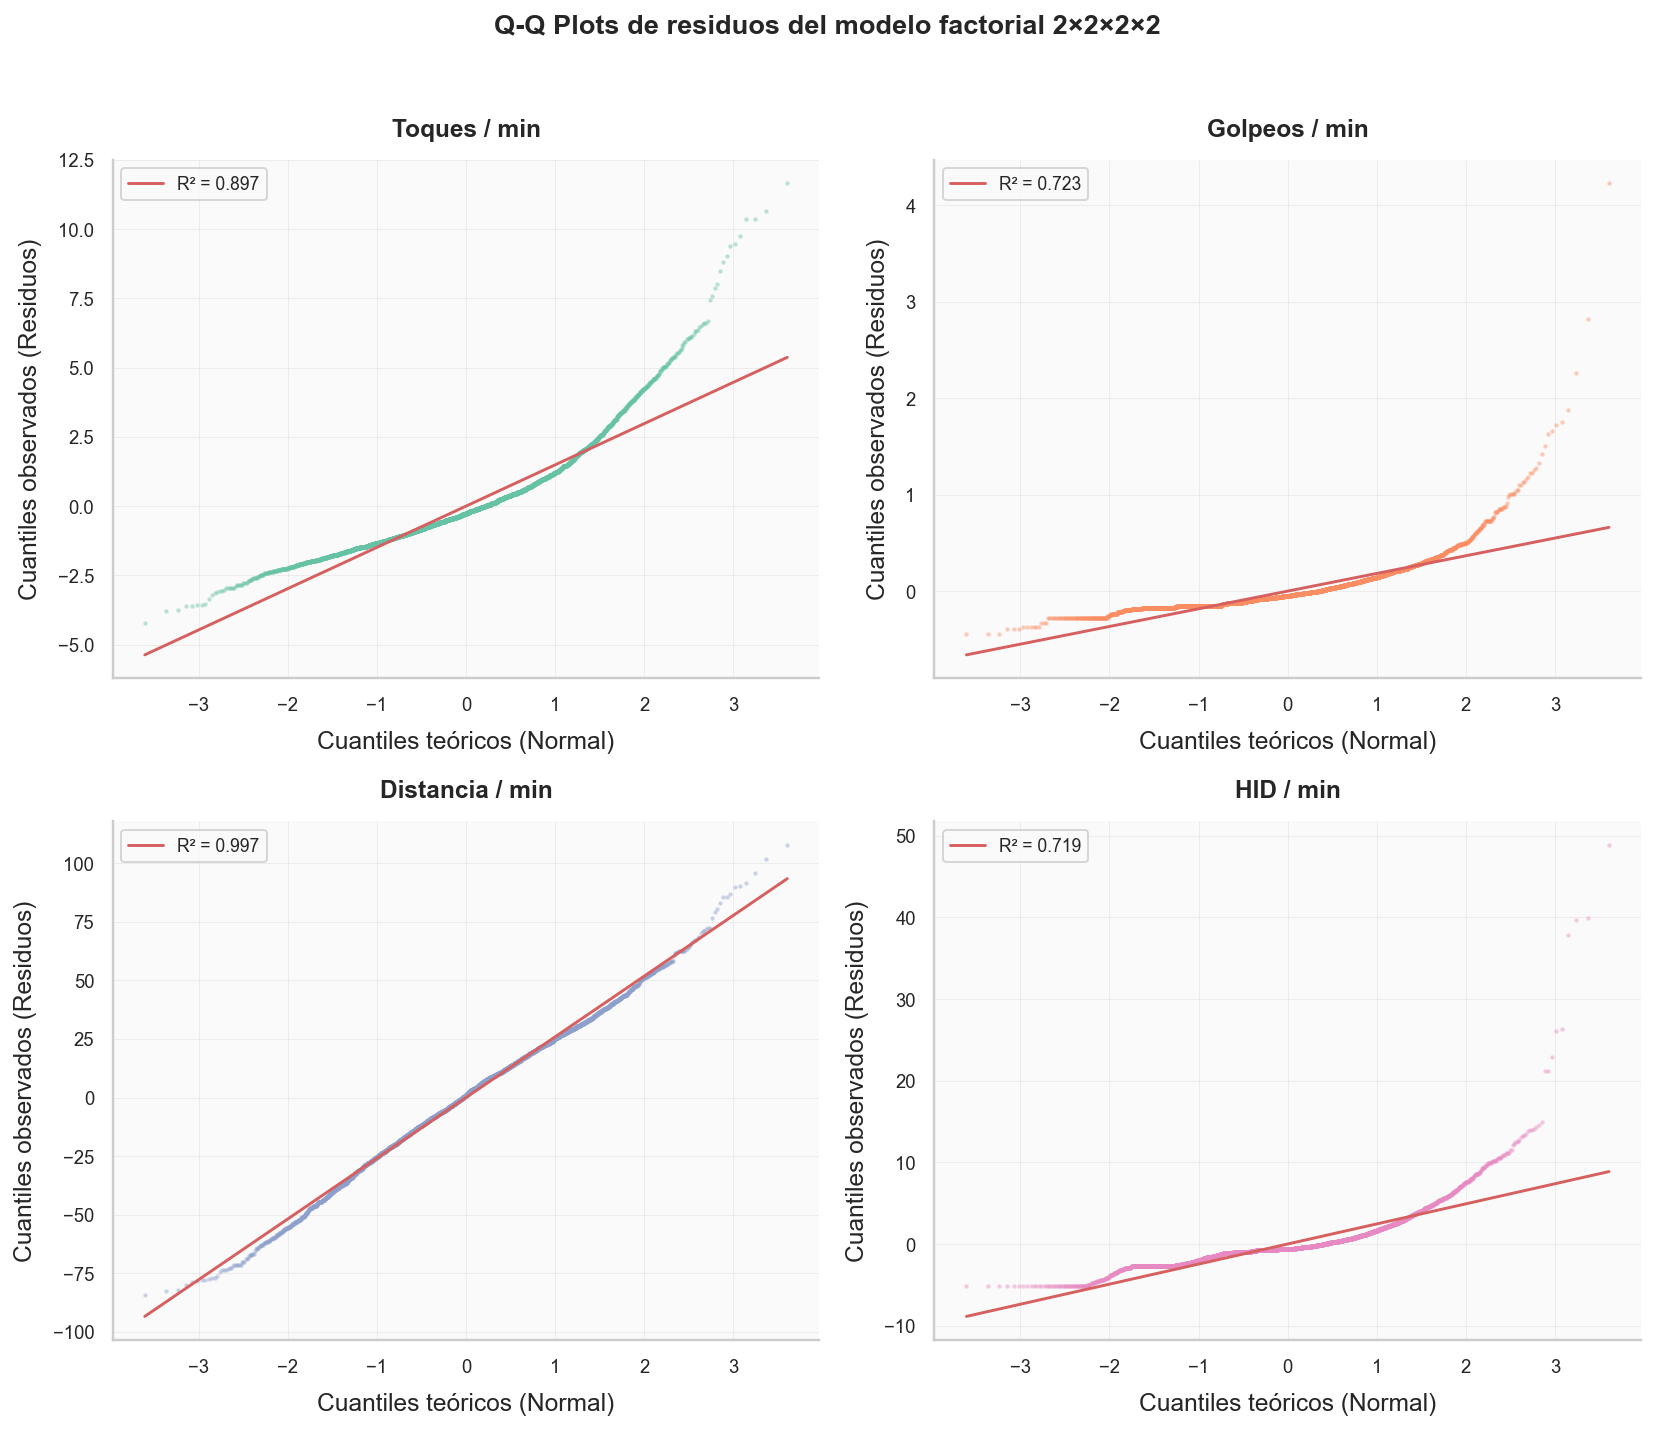

📌 Interpretación: Las colas pesadas (desviación en los extremos) confirman
   la no-normalidad de los residuos, especialmente en Golpeos/min y HID/min.
   Esto es esperado por las distribuciones asimétricas positivas y la zero-inflación.


In [5]:
# ── 1.3  Q-Q plots de residuos ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, vd in enumerate(vd_cols):
    ax = axes[i]
    res = residuos[vd].values
    (osm, osr), (slope, intercept, r) = stats.probplot(res, dist="norm")
    ax.scatter(osm, osr, s=2, alpha=0.3, color=vd_to_color[vd])
    ax.plot(osm, slope * np.array(osm) + intercept, "r-", lw=1.5, label=f"R² = {r**2:.3f}")
    ax.set_title(vd_to_label[vd], fontweight="bold")
    ax.set_xlabel("Cuantiles teóricos (Normal)")
    ax.set_ylabel("Cuantiles observados (Residuos)")
    ax.legend(loc="upper left", fontsize=9)

fig.suptitle("Q-Q Plots de residuos del modelo factorial 2×2×2×2",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("📌 Interpretación: Las colas pesadas (desviación en los extremos) confirman")
print("   la no-normalidad de los residuos, especialmente en Golpeos/min y HID/min.")
print("   Esto es esperado por las distribuciones asimétricas positivas y la zero-inflación.")

In [6]:
# ── 1.4  Test de Levene (homocedasticidad) ───────────────────────────────────
# Se crea la variable de combinación factorial para evaluar la varianza entre
# las 16 celdas del diseño 2×2×2×2

df["Combinacion"] = (
    df["Espacio"] + "-" + df["Agrupacion"] + "-" +
    df["Polaridad"] + "-" + df["Equilibrio"]
)

resultados_levene = []
for vd in vd_cols:
    # Levene basado en medianas (más robusto que basado en medias)
    grupos = [grupo[vd].dropna().values for _, grupo in df.groupby("Combinacion")]
    stat, p_val = levene(*grupos, center="median")
    resultados_levene.append({
        "VD": vd_to_label[vd],
        "Levene F": round(stat, 2),
        "p-valor": f"{p_val:.2e}",
        "Rechaza H₀ (α=.05)": "Sí ⚠️" if p_val < 0.05 else "No",
        "N grupos": len(grupos),
    })

    # Levene por cada VI individual
    for vi in vi_cols:
        niveles = sorted(df[vi].dropna().unique())
        grupos_vi = [df.loc[df[vi] == n, vd].dropna().values for n in niveles]
        stat_vi, p_vi = levene(*grupos_vi, center="median")
        resultados_levene.append({
            "VD": vd_to_label[vd],
            "Levene F": round(stat_vi, 2),
            "p-valor": f"{p_vi:.2e}",
            "Rechaza H₀ (α=.05)": "Sí ⚠️" if p_vi < 0.05 else "No",
            "N grupos": f"{vi}: {len(niveles)} niveles",
        })

df_levene = pd.DataFrame(resultados_levene)
display(Markdown("### Test de Levene (basado en medianas) — Homocedasticidad"))
display(
    df_levene.style
    .set_properties(**{"text-align": "center"})
    .apply(lambda x: ["background-color: #ffe0e0" if "Sí" in str(v) else "" for v in x], axis=1)
)

### Test de Levene (basado en medianas) — Homocedasticidad

,VD,Levene F,p-valor,Rechaza H₀ (α=.05),N grupos
0,Toques / min,30.650000,6.80e-84,Sí ⚠️,16
1,Toques / min,223.300000,2.66e-49,Sí ⚠️,Agrupacion: 2 niveles
2,Toques / min,211.200000,8.77e-47,Sí ⚠️,Espacio: 2 niveles
3,Toques / min,107.540000,6.49e-25,Sí ⚠️,Polaridad: 2 niveles
4,Toques / min,77.200000,2.17e-18,Sí ⚠️,Equilibrio: 2 niveles
5,Golpeos / min,26.670000,2.00e-72,Sí ⚠️,16
6,Golpeos / min,48.960000,3.01e-12,Sí ⚠️,Agrupacion: 2 niveles
7,Golpeos / min,5.030000,2.49e-02,Sí ⚠️,Espacio: 2 niveles
8,Golpeos / min,0.000000,9.57e-01,No,Polaridad: 2 niveles
9,Golpeos / min,7.700000,5.54e-03,Sí ⚠️,Equilibrio: 2 niveles


In [7]:
# ── 1.5  Tabla resumen de supuestos ──────────────────────────────────────────
resumen_supuestos = []
for vd in vd_cols:
    label = vd_to_label[vd]
    res = residuos[vd].values
    asim = stats.skew(res)
    _, p_dag = stats.normaltest(res)

    # Levene del modelo completo (16 celdas)
    grupos = [grupo[vd].dropna().values for _, grupo in df.groupby("Combinacion")]
    _, p_lev = levene(*grupos, center="median")

    resumen_supuestos.append({
        "VD": label,
        "Normalidad (D'Agostino)": f"p = {p_dag:.2e} ❌",
        "Asimetría residuos": f"{asim:+.2f}",
        "Homocedasticidad (Levene 16 celdas)": f"p = {p_lev:.2e}" + (" ❌" if p_lev < 0.05 else " ✅"),
        "Independencia": "Violada ❌ (medidas repetidas)",
        "Zero-inflación": f"{'Sí ⚠️ (~30%)' if vd in vd_zeros else 'No'}",
    })

df_resumen_sup = pd.DataFrame(resumen_supuestos)
display(Markdown("### 📋 Resumen de verificación de supuestos"))
display(Markdown(
    "**Conclusión:** Todos los supuestos del ANOVA clásico están violados en mayor o menor medida. "
    "Esto justifica: (1) el uso de alternativas robustas en el Paso 4, y (2) la necesidad del GLMM "
    "como análisis definitivo. No obstante, el ANOVA clásico sigue siendo informativo como "
    "primera aproximación, especialmente para tamaños de efecto."
))
display(df_resumen_sup.style.set_properties(**{"text-align": "center"}))

### 📋 Resumen de verificación de supuestos

**Conclusión:** Todos los supuestos del ANOVA clásico están violados en mayor o menor medida. Esto justifica: (1) el uso de alternativas robustas en el Paso 4, y (2) la necesidad del GLMM como análisis definitivo. No obstante, el ANOVA clásico sigue siendo informativo como primera aproximación, especialmente para tamaños de efecto.

,VD,Normalidad (D'Agostino),Asimetría residuos,Homocedasticidad (Levene 16 celdas),Independencia,Zero-inflación
0,Toques / min,p = 0.00e+00 ❌,+1.64,p = 6.80e-84 ❌,Violada ❌ (medidas repetidas),No
1,Golpeos / min,p = 0.00e+00 ❌,+4.54,p = 2.00e-72 ❌,Violada ❌ (medidas repetidas),Sí ⚠️ (~30%)
2,Distancia / min,p = 1.60e-05 ❌,-0.12,p = 7.26e-32 ❌,Violada ❌ (medidas repetidas),No
3,HID / min,p = 0.00e+00 ❌,+4.49,p = 9.89e-157 ❌,Violada ❌ (medidas repetidas),Sí ⚠️ (~30%)


---

## Paso 2 — Decisión sobre GrupoEdad

Se evalúan dos opciones para incorporar la variable moderadora `GrupoEdad` (5 niveles):

- **Opción A:** Factorial completo 2×2×2×2×5 → 80 celdas teóricas.
- **Opción B:** ANOVA 2×2×2×2 global + análisis estratificado por GrupoEdad (5 ANOVAs independientes).

La decisión se basa en los **tamaños de celda reales** y la viabilidad estadística de cada opción.

In [8]:
# ── 2.1  Tamaños de celda del factorial 2×2×2×2 (global) ────────────────────
tabla_global = (
    df.groupby(vi_cols)
    .size()
    .reset_index(name="N")
    .sort_values("N", ascending=True)
)

print("=" * 60)
print("TAMAÑOS DE CELDA — Factorial 2×2×2×2 (16 celdas)")
print("=" * 60)
display(tabla_global)
print(f"\nCelda mínima: {tabla_global['N'].min()} obs")
print(f"Celda máxima: {tabla_global['N'].max()} obs")
print(f"Ratio desbalance: {tabla_global['N'].max() / tabla_global['N'].min():.0f}:1")
print(f"Mediana N/celda: {tabla_global['N'].median():.0f}")
print(f"Celdas con N < 50: {(tabla_global['N'] < 50).sum()}")
print(f"Celdas con N < 100: {(tabla_global['N'] < 100).sum()}")

TAMAÑOS DE CELDA — Factorial 2×2×2×2 (16 celdas)


,Agrupacion,Espacio,Polaridad,Equilibrio,N
6,grande,reducido,Polarizado,Desequilibrio,16
8,pequeno,amplio,No_polarizado,Desequilibrio,23
9,pequeno,amplio,No_polarizado,Equilibrio,23
1,grande,amplio,No_polarizado,Equilibrio,55
2,grande,amplio,Polarizado,Desequilibrio,65
10,pequeno,amplio,Polarizado,Desequilibrio,74
0,grande,amplio,No_polarizado,Desequilibrio,81
4,grande,reducido,No_polarizado,Desequilibrio,106
13,pequeno,reducido,No_polarizado,Equilibrio,122
5,grande,reducido,No_polarizado,Equilibrio,124



Celda mínima: 16 obs
Celda máxima: 1461 obs
Ratio desbalance: 91:1
Mediana N/celda: 114
Celdas con N < 50: 3
Celdas con N < 100: 7


In [9]:
# ── 2.2  Tamaños de celda si se incluye GrupoEdad (80 celdas teóricas) ──────
tabla_con_ge = (
    df.groupby(vi_cols + ["GrupoEdad"])
    .size()
    .reset_index(name="N")
    .sort_values("N", ascending=True)
)

# Combinaciones teóricas vs observadas
niveles_ge = sorted(df["GrupoEdad"].dropna().unique())
n_teoricas = 16 * len(niveles_ge)
n_observadas = tabla_con_ge.shape[0]
n_vacias = n_teoricas - n_observadas

print("=" * 60)
print(f"TAMAÑOS DE CELDA — Factorial 2×2×2×2 × GrupoEdad ({n_teoricas} teóricas)")
print("=" * 60)
print(f"Celdas observadas: {n_observadas} de {n_teoricas} teóricas")
print(f"Celdas VACÍAS: {n_vacias}")
print(f"\nCelda mínima (no vacía): {tabla_con_ge['N'].min()} obs")
print(f"Celda máxima: {tabla_con_ge['N'].max()} obs")
print(f"Ratio desbalance: {tabla_con_ge['N'].max() / tabla_con_ge['N'].min():.0f}:1")
print(f"\nDistribución de tamaños de celda:")
print(f"  N < 5:   {(tabla_con_ge['N'] < 5).sum()} celdas")
print(f"  N < 10:  {(tabla_con_ge['N'] < 10).sum()} celdas")
print(f"  N < 20:  {(tabla_con_ge['N'] < 20).sum()} celdas")
print(f"  N < 50:  {(tabla_con_ge['N'] < 50).sum()} celdas")
print(f"  N ≥ 50:  {(tabla_con_ge['N'] >= 50).sum()} celdas")

# Mostrar las 15 celdas más pequeñas
print(f"\n── 15 celdas más pequeñas:")
display(tabla_con_ge.head(15))

TAMAÑOS DE CELDA — Factorial 2×2×2×2 × GrupoEdad (80 teóricas)
Celdas observadas: 54 de 80 teóricas
Celdas VACÍAS: 26

Celda mínima (no vacía): 13 obs
Celda máxima: 495 obs
Ratio desbalance: 38:1

Distribución de tamaños de celda:
  N < 5:   0 celdas
  N < 10:  0 celdas
  N < 20:  11 celdas
  N < 50:  27 celdas
  N ≥ 50:  27 celdas

── 15 celdas más pequeñas:


,Agrupacion,Espacio,Polaridad,Equilibrio,GrupoEdad,N
43,pequeno,reducido,No_polarizado,Equilibrio,Senior Masculino,13
4,grande,amplio,No_polarizado,Equilibrio,Senior Masculino,13
39,pequeno,reducido,No_polarizado,Equilibrio,Cadete,15
7,grande,amplio,Polarizado,Desequilibrio,Senior Masculino,15
28,pequeno,amplio,Polarizado,Desequilibrio,Juvenil,16
16,grande,reducido,No_polarizado,Equilibrio,Infantil,16
19,grande,reducido,Polarizado,Desequilibrio,Infantil,16
46,pequeno,reducido,Polarizado,Desequilibrio,Juvenil,17
42,pequeno,reducido,No_polarizado,Equilibrio,Neskak,19
40,pequeno,reducido,No_polarizado,Equilibrio,Infantil,19


In [10]:
# ── 2.3  Tamaños de celda por estrato de GrupoEdad ──────────────────────────
print("=" * 60)
print("TAMAÑOS DE CELDA — Por estrato de GrupoEdad (16 celdas c/u)")
print("=" * 60)

resumen_estratos = []
for ge in niveles_ge:
    df_ge = df[df["GrupoEdad"] == ge]
    tabla_ge = df_ge.groupby(vi_cols).size().reset_index(name="N")
    n_celdas_obs = tabla_ge.shape[0]
    n_vacias_ge = 16 - n_celdas_obs

    resumen_estratos.append({
        "GrupoEdad": ge,
        "N total": len(df_ge),
        "Celdas pobladas (de 16)": n_celdas_obs,
        "Celdas vacías": n_vacias_ge,
        "N mínimo": tabla_ge["N"].min() if n_celdas_obs > 0 else 0,
        "N máximo": tabla_ge["N"].max() if n_celdas_obs > 0 else 0,
        "N mediana": tabla_ge["N"].median() if n_celdas_obs > 0 else 0,
        "Celdas N < 10": (tabla_ge["N"] < 10).sum(),
        "Celdas N < 20": (tabla_ge["N"] < 20).sum(),
    })

df_estratos = pd.DataFrame(resumen_estratos)
display(df_estratos.style.set_properties(**{"text-align": "center"}))

TAMAÑOS DE CELDA — Por estrato de GrupoEdad (16 celdas c/u)


,GrupoEdad,N total,Celdas pobladas (de 16),Celdas vacías,N mínimo,N máximo,N mediana,Celdas N < 10,Celdas N < 20
0,Cadete,716,9,7,15,270,61.000000,0,1
1,Infantil,625,12,4,16,154,20.500000,0,4
2,Juvenil,1006,10,6,16,322,62.000000,0,2
3,Neskak,1084,11,5,19,495,62.000000,0,1
4,Senior Masculino,1015,12,4,13,255,48.000000,0,3


### 📋 Decisión: **Opción B — ANOVA 2×2×2×2 global + estratificado por GrupoEdad**

**Justificación:**

1. **Celdas vacías y extremadamente pequeñas**: El factorial 2×2×2×2×5 genera celdas con N < 5 e incluso celdas vacías. Esto hace que las estimaciones de interacciones con GrupoEdad sean inestables e interpretables.

2. **El desbalance 91:1 ya es un problema en el 2×2×2×2**: añadir GrupoEdad (con su propio desbalance) lo agrava exponencialmente.

3. **Interacciones de alto orden ininterpretables**: Un factorial de 5 factores genera interacciones de 3, 4 y 5 vías. Con celdas de N < 10, estas interacciones no son estimables de forma fiable.

4. **Coherencia con el EDA (NB05)**: El análisis de moderación por GrupoEdad del EDA ya mostró que los efectos moderadores son pequeños a negligibles. Un enfoque estratificado es suficiente.

**Plan de análisis:**
- **Paso 3:** ANOVA factorial 2×2×2×2 sobre el **dataset global** (N = 4 446).
- **Complemento:** 5 ANOVAs 2×2×2×2 estratificados por GrupoEdad (documentando las limitaciones de los estratos más pequeños).

---

## Paso 3 — ANOVA factorial clásico (Type III SS)

### Justificación del tipo de suma de cuadrados

Se utiliza **Type III SS** porque:
- El diseño es **severamente desbalanceado** (ratio 91:1 entre celdas).
- Con Type III, cada efecto se evalúa controlando por todos los demás, independientemente del orden de entrada.
- Es la opción estándar para diseños desbalanceados (recomendada por SPSS, SAS, y la mayoría de manuales de referencia).

### Decisión sobre interacciones de alto orden

Se incluyen **efectos principales + interacciones de 2 vías**, pero **NO interacciones de 3 y 4 vías** porque:
1. Las celdas más pequeñas (N = 16) no permiten estimar interacciones de alto orden de forma fiable.
2. El EDA (NB04) mostró que incluso las interacciones 2-way tienen η²p uniformemente pequeños (máx. 0.0224).
3. Con 4 factores binarios, las interacciones de 3 y 4 vías carecen de interpretabilidad práctica en contexto deportivo.
4. Se prioriza la **parsimonia** y la **interpretabilidad** sobre la complejidad del modelo.

In [11]:
# ── 3.1  ANOVA Type III — Modelo global 2×2×2×2 ─────────────────────────────
# Se usa statsmodels con codificación efectos (sum-to-zero) requerida para
# Type III SS cuando hay desbalance

from statsmodels.stats.anova import anova_lm

# Fórmula con efectos principales + todas las interacciones 2-way
formula_modelo = (
    "Q('{vd}') ~ C(Agrupacion, Sum) * C(Espacio, Sum) + "
    "C(Agrupacion, Sum) * C(Polaridad, Sum) + "
    "C(Agrupacion, Sum) * C(Equilibrio, Sum) + "
    "C(Espacio, Sum) * C(Polaridad, Sum) + "
    "C(Espacio, Sum) * C(Equilibrio, Sum) + "
    "C(Polaridad, Sum) * C(Equilibrio, Sum)"
)

# Almacenar resultados
resultados_anova = {}
tablas_anova = {}

for vd in vd_cols:
    f = formula_modelo.format(vd=vd)
    modelo = ols(f, data=df).fit()
    tabla = anova_lm(modelo, typ=3)

    # Renombrar índices para legibilidad
    rename_map = {
        "C(Agrupacion, Sum)": "Agrupacion",
        "C(Espacio, Sum)": "Espacio",
        "C(Polaridad, Sum)": "Polaridad",
        "C(Equilibrio, Sum)": "Equilibrio",
        "C(Agrupacion, Sum):C(Espacio, Sum)": "Agrupacion × Espacio",
        "C(Agrupacion, Sum):C(Polaridad, Sum)": "Agrupacion × Polaridad",
        "C(Agrupacion, Sum):C(Equilibrio, Sum)": "Agrupacion × Equilibrio",
        "C(Espacio, Sum):C(Polaridad, Sum)": "Espacio × Polaridad",
        "C(Espacio, Sum):C(Equilibrio, Sum)": "Espacio × Equilibrio",
        "C(Polaridad, Sum):C(Equilibrio, Sum)": "Polaridad × Equilibrio",
    }
    tabla.index = [rename_map.get(i, i) for i in tabla.index]

    # Calcular eta-parcial al cuadrado
    ss_residual = tabla.loc["Residual", "sum_sq"]
    tabla["η²p"] = tabla["sum_sq"] / (tabla["sum_sq"] + ss_residual)
    tabla.loc["Residual", "η²p"] = np.nan

    # Interpretación
    tabla["Interpretación"] = tabla["η²p"].apply(
        lambda x: interpretar_eta2p(x) if pd.notna(x) else ""
    )
    tabla["Sig."] = tabla["PR(>F)"].apply(
        lambda x: estrellas_p(x) if pd.notna(x) else ""
    )

    tablas_anova[vd] = tabla
    resultados_anova[vd] = modelo

print("✅ ANOVA Type III completado para las 4 VD.")

✅ ANOVA Type III completado para las 4 VD.


In [12]:
# ── 3.2  Mostrar tablas ANOVA para cada VD ───────────────────────────────────
for vd in vd_cols:
    tabla = tablas_anova[vd]
    display(Markdown(f"### ANOVA Type III — **{vd_to_label[vd]}**"))

    # Formatear para presentación
    tabla_show = tabla[["sum_sq", "df", "F", "PR(>F)", "η²p", "Interpretación", "Sig."]].copy()
    tabla_show.columns = ["SS", "gl", "F", "p-valor", "η²p", "Magnitud", "Sig."]
    tabla_show = tabla_show[tabla_show.index != "Intercept"]  # Excluir intercepto

    # Formatear números
    for col in ["SS", "F", "η²p"]:
        tabla_show[col] = tabla_show[col].apply(
            lambda x: f"{x:.4f}" if pd.notna(x) and col == "η²p"
            else (f"{x:.2f}" if pd.notna(x) else "")
        )
    tabla_show["gl"] = tabla_show["gl"].apply(lambda x: f"{x:.0f}" if pd.notna(x) else "")
    tabla_show["p-valor"] = tabla_show["p-valor"].apply(
        lambda x: f"{x:.2e}" if pd.notna(x) and x < 0.001 else (f"{x:.4f}" if pd.notna(x) else "")
    )

    display(tabla_show)
    print()

### ANOVA Type III — **Toques / min**

,SS,gl,F,p-valor,η²p,Magnitud,Sig.
Agrupacion,187.48,1,75.65,4.70e-18,0.0168,Pequeño,***
Espacio,109.08,1,44.01,3.65e-11,0.0098,Negligible,***
Polaridad,493.99,1,199.33,2.63e-44,0.0430,Pequeño,***
Equilibrio,2.98,1,1.20,0.2732,0.0003,Negligible,ns
Agrupacion × Espacio,32.06,1,12.94,3.26e-04,0.0029,Negligible,***
Agrupacion × Polaridad,113.53,1,45.81,1.47e-11,0.0102,Pequeño,***
Agrupacion × Equilibrio,20.96,1,8.46,0.0037,0.0019,Negligible,**
Espacio × Polaridad,46.52,1,18.77,1.51e-05,0.0042,Negligible,***
Espacio × Equilibrio,1.15,1,0.46,0.4967,0.0001,Negligible,ns
Polaridad × Equilibrio,24.05,1,9.70,0.0019,0.0022,Negligible,**


### ANOVA Type III — **Golpeos / min**

,SS,gl,F,p-valor,η²p,Magnitud,Sig.
Agrupacion,3.18,1,68.36,1.78e-16,0.0152,Pequeño,***
Espacio,4.68,1,100.65,1.94e-23,0.0222,Pequeño,***
Polaridad,0.01,1,0.22,0.6378,0.0000,Negligible,ns
Equilibrio,0.04,1,0.80,0.3721,0.0002,Negligible,ns
Agrupacion × Espacio,3.68,1,79.10,8.46e-19,0.0175,Pequeño,***
Agrupacion × Polaridad,1.64,1,35.20,3.20e-09,0.0079,Negligible,***
Agrupacion × Equilibrio,0.37,1,7.89,0.0050,0.0018,Negligible,**
Espacio × Polaridad,2.95,1,63.50,2.02e-15,0.0141,Pequeño,***
Espacio × Equilibrio,0.39,1,8.48,0.0036,0.0019,Negligible,**
Polaridad × Equilibrio,0.12,1,2.64,0.1044,0.0006,Negligible,ns


### ANOVA Type III — **Distancia / min**

,SS,gl,F,p-valor,η²p,Magnitud,Sig.
Agrupacion,124987.81,1,185.49,2.06e-41,0.0401,Pequeño,***
Espacio,1698.63,1,2.52,0.1124,0.0006,Negligible,ns
Polaridad,15475.08,1,22.97,1.70e-06,0.0052,Negligible,***
Equilibrio,14573.31,1,21.63,3.41e-06,0.0049,Negligible,***
Agrupacion × Espacio,46564.03,1,69.11,1.23e-16,0.0153,Pequeño,***
Agrupacion × Polaridad,684.23,1,1.02,0.3137,0.0002,Negligible,ns
Agrupacion × Equilibrio,1680.42,1,2.49,0.1144,0.0006,Negligible,ns
Espacio × Polaridad,13.82,1,0.02,0.8861,0.0000,Negligible,ns
Espacio × Equilibrio,332.86,1,0.49,0.4822,0.0001,Negligible,ns
Polaridad × Equilibrio,114.80,1,0.17,0.6798,0.0000,Negligible,ns


### ANOVA Type III — **HID / min**

,SS,gl,F,p-valor,η²p,Magnitud,Sig.
Agrupacion,373.03,1,44.30,3.15e-11,0.0099,Negligible,***
Espacio,615.51,1,73.10,1.67e-17,0.0162,Pequeño,***
Polaridad,211.88,1,25.16,5.47e-07,0.0056,Negligible,***
Equilibrio,145.13,1,17.24,3.36e-05,0.0039,Negligible,***
Agrupacion × Espacio,850.22,1,100.98,1.66e-23,0.0223,Pequeño,***
Agrupacion × Polaridad,21.81,1,2.59,0.1076,0.0006,Negligible,ns
Agrupacion × Equilibrio,5.56,1,0.66,0.4164,0.0001,Negligible,ns
Espacio × Polaridad,192.21,1,22.83,1.83e-06,0.0051,Negligible,***
Espacio × Equilibrio,574.50,1,68.23,1.90e-16,0.0152,Pequeño,***
Polaridad × Equilibrio,19.15,1,2.27,0.1316,0.0005,Negligible,ns


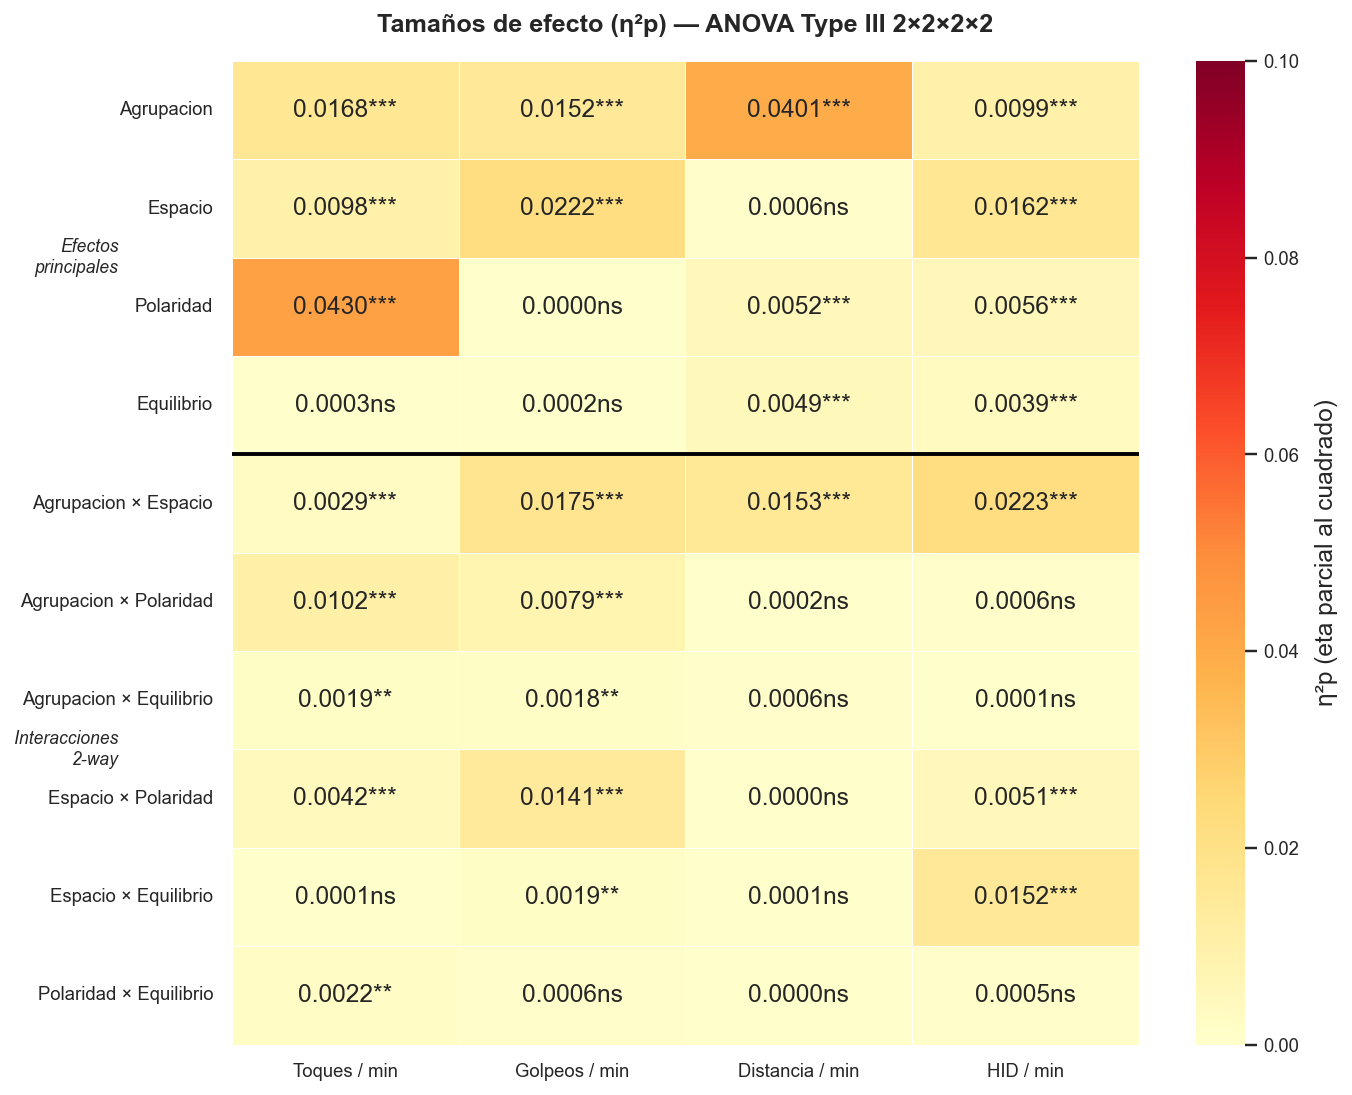

📌 Leyenda: *** p<.001 | ** p<.01 | * p<.05 | ns no significativo
📌 Umbrales η²p: <.01 negligible | .01-.06 pequeño | .06-.14 medio | >.14 grande


In [13]:
# ── 3.3  Heatmap de η²p (Efectos × VD) ──────────────────────────────────────
# Construir matriz de η²p para el heatmap
efectos = [
    "Agrupacion", "Espacio", "Polaridad", "Equilibrio",
    "Agrupacion × Espacio", "Agrupacion × Polaridad",
    "Agrupacion × Equilibrio", "Espacio × Polaridad",
    "Espacio × Equilibrio", "Polaridad × Equilibrio",
]

matriz_eta2p = pd.DataFrame(index=efectos, columns=vd_labels)
matriz_pval = pd.DataFrame(index=efectos, columns=vd_labels)

for vd in vd_cols:
    tabla = tablas_anova[vd]
    for efecto in efectos:
        if efecto in tabla.index:
            matriz_eta2p.loc[efecto, vd_to_label[vd]] = tabla.loc[efecto, "η²p"]
            matriz_pval.loc[efecto, vd_to_label[vd]] = tabla.loc[efecto, "PR(>F)"]

matriz_eta2p = matriz_eta2p.astype(float)
matriz_pval = matriz_pval.astype(float)

# Generar anotaciones con η²p y estrellas de significación
annot_matrix = pd.DataFrame(index=efectos, columns=vd_labels, dtype=str)
for ef in efectos:
    for vl in vd_labels:
        eta = matriz_eta2p.loc[ef, vl]
        p = matriz_pval.loc[ef, vl]
        annot_matrix.loc[ef, vl] = f"{eta:.4f}{estrellas_p(p)}"

# Separar efectos principales e interacciones con una línea
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    matriz_eta2p,
    annot=annot_matrix.values,
    fmt="",
    cmap="YlOrRd",
    vmin=0,
    vmax=max(0.10, matriz_eta2p.max().max() * 1.1),
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "η²p (eta parcial al cuadrado)"},
)
ax.set_title(
    "Tamaños de efecto (η²p) — ANOVA Type III 2×2×2×2",
    fontsize=13, fontweight="bold", pad=15,
)
ax.set_ylabel("")
ax.set_xlabel("")

# Línea separadora entre efectos principales e interacciones
ax.axhline(y=4, color="black", linewidth=2)
ax.text(-0.5, 2, "Efectos\nprincipales", ha="right", va="center", fontsize=9, fontstyle="italic")
ax.text(-0.5, 7, "Interacciones\n2-way", ha="right", va="center", fontsize=9, fontstyle="italic")

plt.tight_layout()
plt.show()

print("📌 Leyenda: *** p<.001 | ** p<.01 | * p<.05 | ns no significativo")
print("📌 Umbrales η²p: <.01 negligible | .01-.06 pequeño | .06-.14 medio | >.14 grande")

Top 4 interacciones por η²p medio:
  1. Agrupacion × Espacio: η²p medio = 0.0145
  2. Espacio × Polaridad: η²p medio = 0.0059
  3. Agrupacion × Polaridad: η²p medio = 0.0047
  4. Espacio × Equilibrio: η²p medio = 0.0043


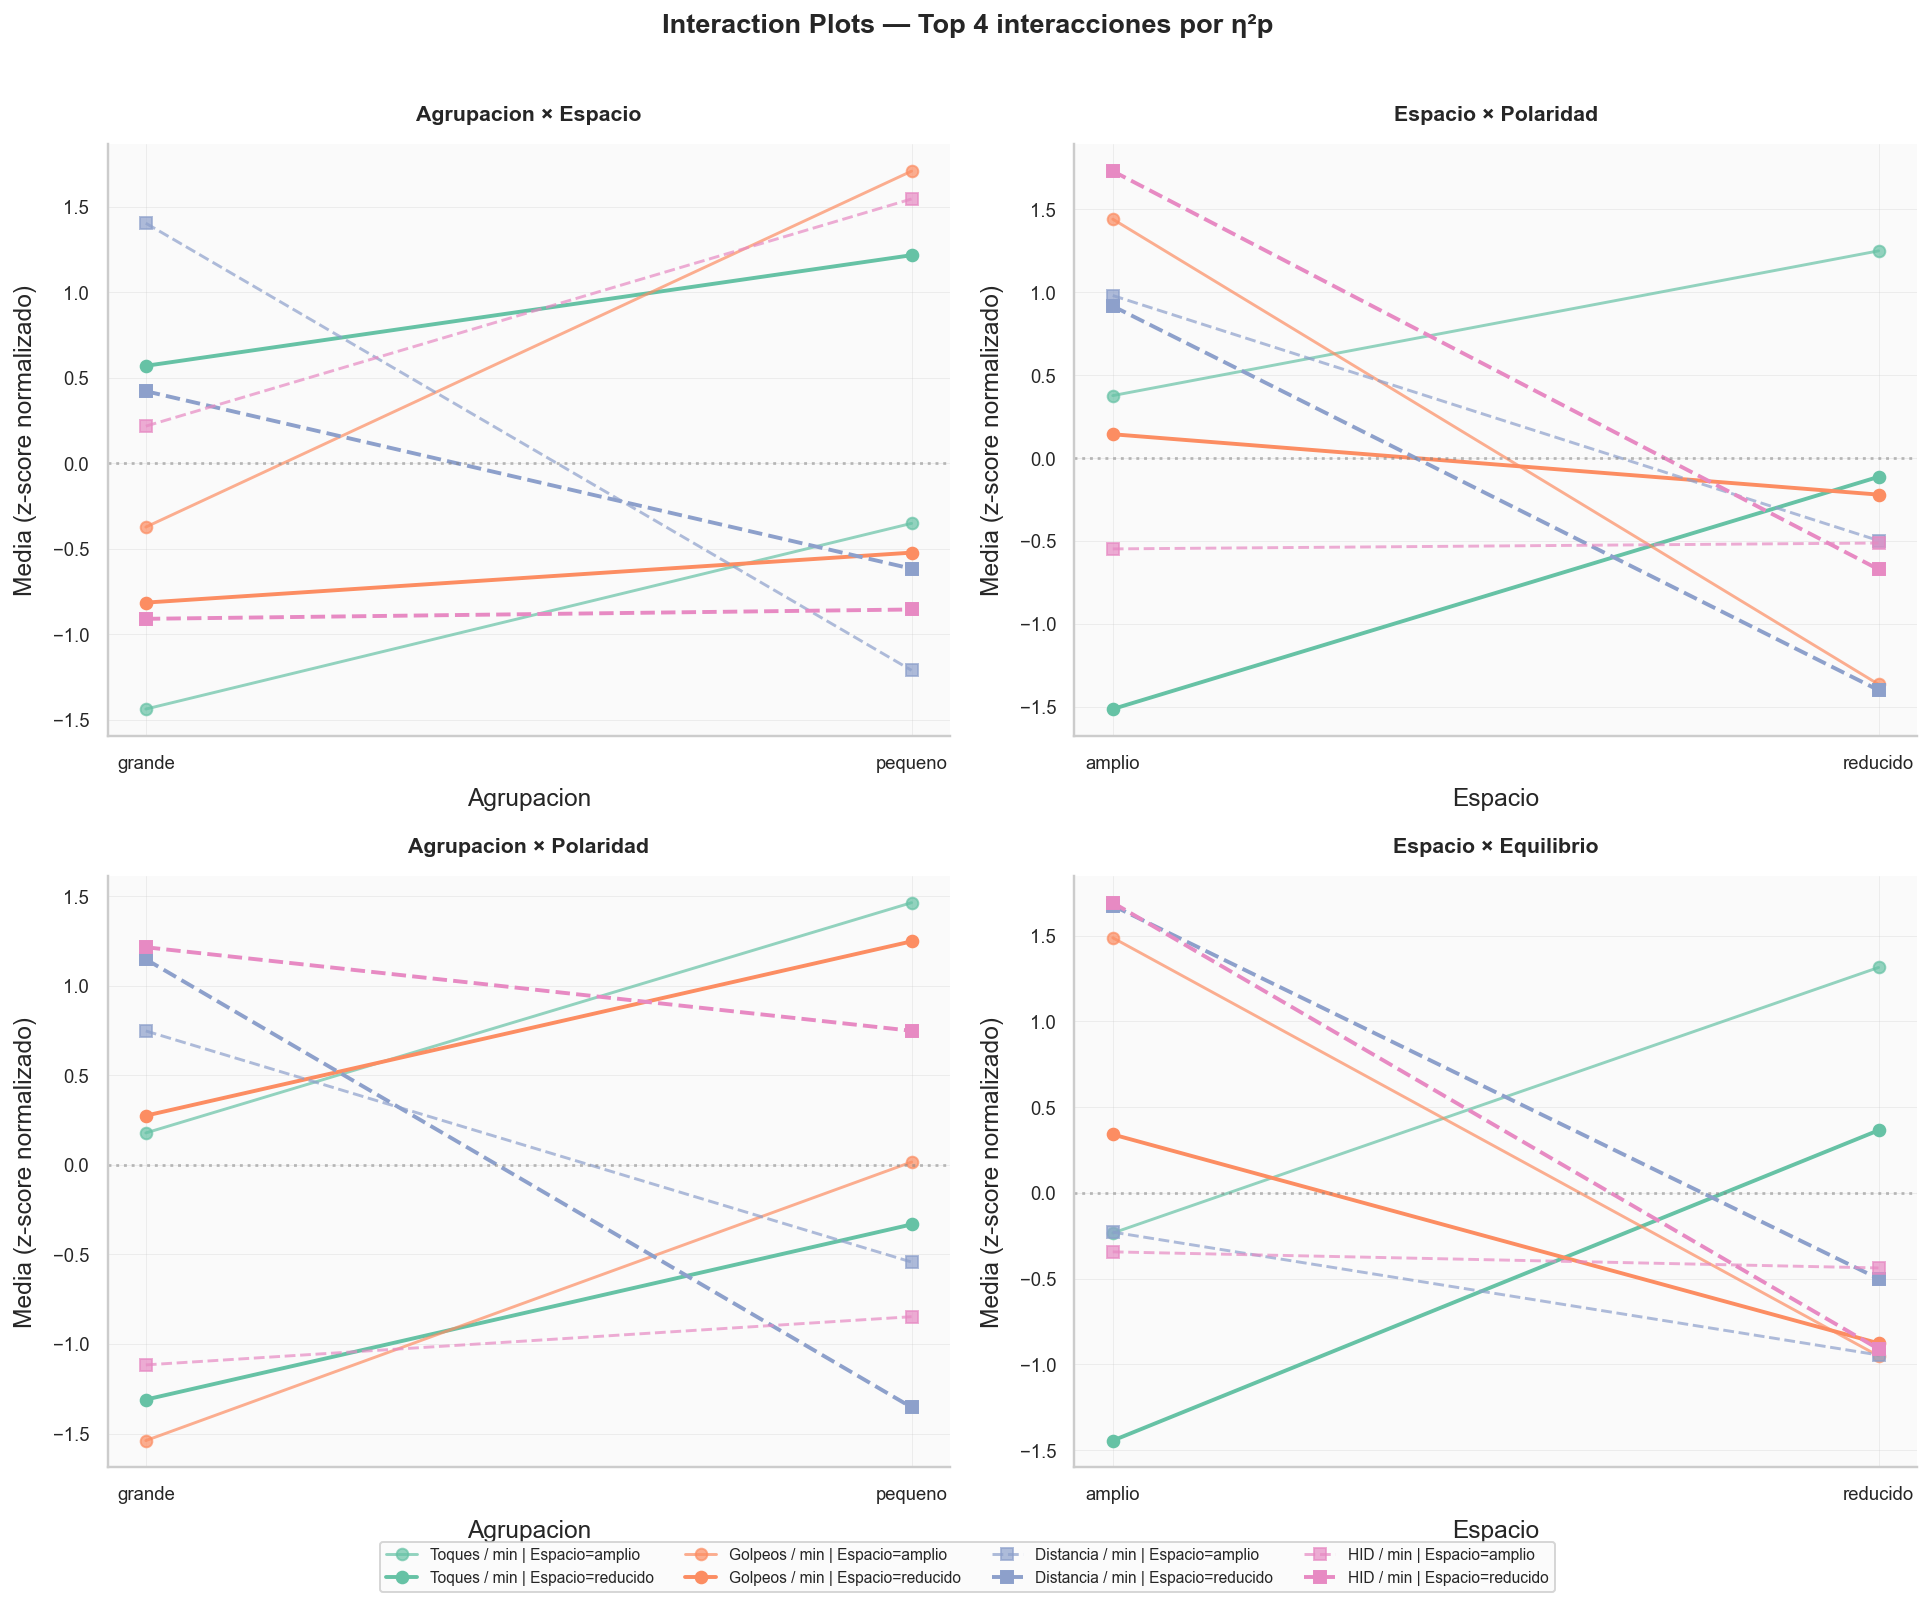

In [14]:
# ── 3.4  Interaction plots para las interacciones más relevantes ──────────────
# Seleccionar las 4 interacciones con mayor η²p promedio

interacciones_ranking = (
    matriz_eta2p.loc[
        [e for e in efectos if "×" in e]
    ]
    .mean(axis=1)
    .sort_values(ascending=False)
)

top_interacciones = interacciones_ranking.head(4).index.tolist()
print("Top 4 interacciones por η²p medio:")
for i, inter in enumerate(top_interacciones, 1):
    print(f"  {i}. {inter}: η²p medio = {interacciones_ranking[inter]:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

for idx, inter_name in enumerate(top_interacciones):
    ax = axes[idx]
    # Parsear los dos factores de la interacción
    vi_a, vi_b = [x.strip() for x in inter_name.split("×")]

    for k, vd in enumerate(vd_cols):
        # Calcular medias marginales por combinación
        medias = df.groupby([vi_a, vi_b])[vd].mean().unstack()

        # Normalizar para poder comparar VDs en el mismo gráfico
        medias_norm = (medias - medias.values.mean()) / medias.values.std()

        for col in medias_norm.columns:
            estilo = "-o" if k < 2 else "--s"
            ax.plot(
                medias_norm.index, medias_norm[col],
                estilo, label=f"{vd_to_label[vd]} | {vi_b}={col}",
                color=vd_to_color[vd],
                alpha=0.7 if col == medias_norm.columns[0] else 1.0,
                linewidth=1.5 if col == medias_norm.columns[0] else 2.0,
            )

    ax.set_title(f"{inter_name}", fontweight="bold", fontsize=11)
    ax.set_xlabel(vi_a)
    ax.set_ylabel("Media (z-score normalizado)")
    ax.axhline(0, color="gray", linestyle=":", alpha=0.5)

# Leyenda compartida debajo
handles, labels = axes[0].get_legend_handles_labels()
# Tomar solo las primeras 8 entradas (evitar duplicados)
fig.legend(
    handles[:8], labels[:8],
    loc="lower center", ncol=4, fontsize=8,
    bbox_to_anchor=(0.5, -0.02),
)
fig.suptitle(
    "Interaction Plots — Top 4 interacciones por η²p",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

In [15]:
# ── 3.5  ANOVAs estratificados por GrupoEdad ─────────────────────────────────
# Se ejecuta un ANOVA 2×2×2×2 independiente por cada estrato de GrupoEdad

resultados_estratificados = []

for ge in niveles_ge:
    df_ge = df[df["GrupoEdad"] == ge].copy()
    n_ge = len(df_ge)

    # Verificar que hay suficientes datos en todas las combinaciones
    tabla_ge = df_ge.groupby(vi_cols).size()
    min_celda = tabla_ge.min()
    n_celdas = len(tabla_ge)

    for vd in vd_cols:
        try:
            f = formula_modelo.format(vd=vd)
            modelo_ge = ols(f, data=df_ge).fit()
            tabla = anova_lm(modelo_ge, typ=3)

            # Renombrar índices
            tabla.index = [
                {
                    "C(Agrupacion, Sum)": "Agrupacion",
                    "C(Espacio, Sum)": "Espacio",
                    "C(Polaridad, Sum)": "Polaridad",
                    "C(Equilibrio, Sum)": "Equilibrio",
                    "C(Agrupacion, Sum):C(Espacio, Sum)": "Agrupacion × Espacio",
                    "C(Agrupacion, Sum):C(Polaridad, Sum)": "Agrupacion × Polaridad",
                    "C(Agrupacion, Sum):C(Equilibrio, Sum)": "Agrupacion × Equilibrio",
                    "C(Espacio, Sum):C(Polaridad, Sum)": "Espacio × Polaridad",
                    "C(Espacio, Sum):C(Equilibrio, Sum)": "Espacio × Equilibrio",
                    "C(Polaridad, Sum):C(Equilibrio, Sum)": "Polaridad × Equilibrio",
                }.get(i, i) for i in tabla.index
            ]

            ss_res = tabla.loc["Residual", "sum_sq"]

            for efecto in efectos:
                if efecto in tabla.index:
                    eta2p = tabla.loc[efecto, "sum_sq"] / (tabla.loc[efecto, "sum_sq"] + ss_res)
                    p = tabla.loc[efecto, "PR(>F)"]
                    resultados_estratificados.append({
                        "GrupoEdad": ge,
                        "N": n_ge,
                        "Min celda": min_celda,
                        "VD": vd_to_label[vd],
                        "Efecto": efecto,
                        "F": tabla.loc[efecto, "F"],
                        "p-valor": p,
                        "η²p": eta2p,
                        "Sig.": estrellas_p(p),
                    })
        except Exception as e:
            print(f"  ⚠️ Error en {ge} × {vd_to_label[vd]}: {e}")

df_estrat = pd.DataFrame(resultados_estratificados)
print(f"✅ ANOVAs estratificados completados: {len(df_estrat)} combinaciones efecto×VD×GrupoEdad")

✅ ANOVAs estratificados completados: 200 combinaciones efecto×VD×GrupoEdad


In [16]:
# ── 3.6  Heatmap de significación por GrupoEdad ──────────────────────────────
# Para cada efecto principal, comparar η²p y significación entre estratos

efectos_principales = ["Agrupacion", "Espacio", "Polaridad", "Equilibrio"]

for vd_label in vd_labels:
    df_sub = df_estrat[
        (df_estrat["VD"] == vd_label) &
        (df_estrat["Efecto"].isin(efectos_principales))
    ]

    if df_sub.empty:
        continue

    pivot_eta = df_sub.pivot_table(
        index="Efecto", columns="GrupoEdad", values="η²p"
    ).reindex(index=efectos_principales, columns=niveles_ge)

    pivot_sig = df_sub.pivot_table(
        index="Efecto", columns="GrupoEdad", values="Sig.", aggfunc="first"
    ).reindex(index=efectos_principales, columns=niveles_ge)

    # Anotación: η²p + estrellas
    annot = pivot_eta.copy().astype(str)
    for ef in efectos_principales:
        for ge in niveles_ge:
            try:
                eta_val = pivot_eta.loc[ef, ge]
                sig_val = pivot_sig.loc[ef, ge]
                annot.loc[ef, ge] = f"{eta_val:.3f}{sig_val}" if pd.notna(eta_val) else ""
            except (KeyError, TypeError):
                annot.loc[ef, ge] = ""

display(Markdown(f"### Efectos principales por GrupoEdad — **{vd_label}**"))
display(
    pivot_eta.style
    .format("{:.4f}", na_rep="—")
    .background_gradient(cmap="YlOrRd", vmin=0, vmax=0.15, axis=None)
    .set_caption(f"η²p — {vd_label}")
)

### Efectos principales por GrupoEdad — **HID / min**

GrupoEdad,Cadete,Infantil,Juvenil,Neskak,Senior Masculino
Efecto,,,,,
Agrupacion,0.0006,0.0007,0.0381,0.0078,0.0268
Espacio,0.0060,0.0173,0.0042,0.0608,0.0027
Polaridad,0.0302,0.0004,0.1109,0.0021,0.0057
Equilibrio,0.0625,0.0119,0.0644,0.0033,0.0148


---

## Paso 4 — Alternativas robustas al ANOVA clásico

### Justificación de la alternativa elegida: **ANOVA por permutaciones**

Se elige el ANOVA por permutaciones como alternativa robusta principal por las siguientes razones:

1. **No asume distribución específica**: perfecto para datos con asimetría positiva, zero-inflación y colas pesadas.
2. **Mantiene la estructura factorial**: permite evaluar efectos principales e interacciones de forma conjunta, a diferencia del Welch ANOVA (solo efectos principales).
3. **Implementación sencilla y transparente**: se basa en la redistribución aleatoria de datos y comparación del estadístico F observado con la distribución permutada.
4. **Robusto a heterocedasticidad**: la inferencia es exacta bajo H₀, sin depender de supuestos distribucionales.

**Nota:** Se complementa con el **Welch ANOVA** (vía `pingouin.welch_anova`) para los efectos principales, como verificación adicional.

In [17]:
# ── 4.1  ANOVA por permutaciones ─────────────────────────────────────────────
# Implementación: se permutan las etiquetas de las VD y se recalcula el F del
# ANOVA Type III para cada permutación. El p-valor es la proporción de F
# permutados ≥ F observado.

N_PERM = 5000  # número de permutaciones (5000 para buena precisión)
np.random.seed(42)

resultados_perm = {}

for vd in vd_cols:
    print(f"\n🔄 Permutaciones para {vd_to_label[vd]}...", end=" ")

    # F observados del ANOVA clásico
    tabla_obs = tablas_anova[vd]
    f_observados = {}
    for efecto in efectos:
        if efecto in tabla_obs.index:
            f_observados[efecto] = tabla_obs.loc[efecto, "F"]

    # Distribución nula por permutación
    f_perm_counts = {ef: 0 for ef in f_observados}

    for perm_i in range(N_PERM):
        # Permutar la VD (rompe la asociación VD-VI)
        df_perm = df.copy()
        df_perm[vd] = np.random.permutation(df[vd].values)

        # Ajustar modelo con datos permutados
        f = formula_modelo.format(vd=vd)
        try:
            modelo_perm = ols(f, data=df_perm).fit()
            tabla_perm = anova_lm(modelo_perm, typ=3)

            # Renombrar
            rename_map = {
                "C(Agrupacion, Sum)": "Agrupacion",
                "C(Espacio, Sum)": "Espacio",
                "C(Polaridad, Sum)": "Polaridad",
                "C(Equilibrio, Sum)": "Equilibrio",
                "C(Agrupacion, Sum):C(Espacio, Sum)": "Agrupacion × Espacio",
                "C(Agrupacion, Sum):C(Polaridad, Sum)": "Agrupacion × Polaridad",
                "C(Agrupacion, Sum):C(Equilibrio, Sum)": "Agrupacion × Equilibrio",
                "C(Espacio, Sum):C(Polaridad, Sum)": "Espacio × Polaridad",
                "C(Espacio, Sum):C(Equilibrio, Sum)": "Espacio × Equilibrio",
                "C(Polaridad, Sum):C(Equilibrio, Sum)": "Polaridad × Equilibrio",
            }
            tabla_perm.index = [rename_map.get(i, i) for i in tabla_perm.index]

            for ef in f_observados:
                if ef in tabla_perm.index:
                    f_perm = tabla_perm.loc[ef, "F"]
                    if f_perm >= f_observados[ef]:
                        f_perm_counts[ef] += 1
        except Exception:
            pass

    # p-valores por permutación
    p_perm = {ef: (f_perm_counts[ef] + 1) / (N_PERM + 1) for ef in f_observados}
    resultados_perm[vd] = p_perm
    print(f"✅ ({N_PERM} permutaciones)")

print(f"\n✅ ANOVA por permutaciones completado para las 4 VD.")


🔄 Permutaciones para Toques / min... ✅ (5000 permutaciones)

🔄 Permutaciones para Golpeos / min... ✅ (5000 permutaciones)

🔄 Permutaciones para Distancia / min... ✅ (5000 permutaciones)

🔄 Permutaciones para HID / min... ✅ (5000 permutaciones)

✅ ANOVA por permutaciones completado para las 4 VD.


In [18]:
# ── 4.2  Welch ANOVA para efectos principales (complemento) ─────────────────
# pingouin.welch_anova solo evalúa efectos principales (un factor a la vez)

resultados_welch = []

for vd in vd_cols:
    for vi in vi_cols:
        try:
            resultado = pg.welch_anova(dv=vd, between=vi, data=df)
            f_val = resultado["F"].values[0]
            p_val = resultado["p-unc"].values[0]
            ddof1 = resultado["ddof1"].values[0]
            ddof2 = resultado["ddof2"].values[0]

            # Calcular η²p manualmente (SS_between / (SS_between + SS_within))
            # Usamos la aproximación: η²p ≈ F * df1 / (F * df1 + df2)
            eta2p_approx = (f_val * ddof1) / (f_val * ddof1 + ddof2)

            resultados_welch.append({
                "VD": vd_to_label[vd],
                "VI": vi,
                "F Welch": round(f_val, 2),
                "gl₁": ddof1,
                "gl₂": round(ddof2, 1),
                "p Welch": p_val,
                "η²p (aprox)": round(eta2p_approx, 4),
                "Sig.": estrellas_p(p_val),
            })
        except Exception as e:
            print(f"  ⚠️ Error: {vi} × {vd_to_label[vd]}: {e}")

df_welch = pd.DataFrame(resultados_welch)
display(Markdown("### Welch ANOVA — Efectos principales (robusto a heterocedasticidad)"))
display(
    df_welch.style
    .format({"p Welch": "{:.2e}", "η²p (aprox)": "{:.4f}"})
    .set_properties(**{"text-align": "center"})
)

### Welch ANOVA — Efectos principales (robusto a heterocedasticidad)

,VD,VI,F Welch,gl₁,gl₂,p Welch,η²p (aprox),Sig.
0,Toques / min,Agrupacion,375.230000,1,3745.800000,9.60e-80,0.0911,***
1,Toques / min,Espacio,677.090000,1,4146.300000,2.14e-138,0.1404,***
2,Toques / min,Polaridad,420.890000,1,1256.100000,6.73e-81,0.2510,***
3,Toques / min,Equilibrio,233.260000,1,1556.500000,3.55e-49,0.1303,***
4,Golpeos / min,Agrupacion,18.100000,1,3561.300000,2.15e-05,0.0051,***
5,Golpeos / min,Espacio,39.590000,1,4023.900000,3.47e-10,0.0097,***
6,Golpeos / min,Polaridad,20.130000,1,1363.000000,7.85e-06,0.0146,***
7,Golpeos / min,Equilibrio,0.670000,1,1592.500000,4.14e-01,0.0004,ns
8,Distancia / min,Agrupacion,656.970000,1,4358.000000,4.42e-135,0.1310,***
9,Distancia / min,Espacio,214.310000,1,4193.700000,2.29e-47,0.0486,***


In [19]:
# ── 4.3  Tabla comparativa: ANOVA clásico vs. Permutaciones vs. Welch ────────

filas_comparativa = []

for vd in vd_cols:
    tabla_clasico = tablas_anova[vd]
    p_perm_vd = resultados_perm[vd]

    for efecto in efectos:
        if efecto not in tabla_clasico.index:
            continue

        p_clasico = tabla_clasico.loc[efecto, "PR(>F)"]
        eta2p = tabla_clasico.loc[efecto, "η²p"]
        p_permutacion = p_perm_vd.get(efecto, np.nan)

        # Welch (solo para efectos principales)
        p_welch_val = np.nan
        if "×" not in efecto:
            fila_w = df_welch[
                (df_welch["VD"] == vd_to_label[vd]) &
                (df_welch["VI"] == efecto)
            ]
            if len(fila_w) > 0:
                p_welch_val = fila_w["p Welch"].values[0]

        # ¿Coinciden las conclusiones?
        sig_clasico = p_clasico < 0.05
        sig_perm = p_permutacion < 0.05 if pd.notna(p_permutacion) else None
        sig_welch = p_welch_val < 0.05 if pd.notna(p_welch_val) else None

        coincide = "Sí ✅"
        metodos_sig = [sig_clasico, sig_perm]
        if sig_welch is not None:
            metodos_sig.append(sig_welch)
        if len(set([x for x in metodos_sig if x is not None])) > 1:
            coincide = "No ⚠️"

        filas_comparativa.append({
            "VD": vd_to_label[vd],
            "Efecto": efecto,
            "η²p": eta2p,
            "p Clásico": p_clasico,
            "p Permutación": p_permutacion,
            "p Welch": p_welch_val,
            "¿Coinciden?": coincide,
        })

df_comp = pd.DataFrame(filas_comparativa)

display(Markdown("### 📊 Tabla comparativa: ANOVA clásico vs. alternativas robustas"))
display(Markdown(
    "Si los tres métodos coinciden en la decisión (significativo/no significativo), "
    "la conclusión es más robusta. Las discrepancias señalan efectos sensibles a las "
    "violaciones de supuestos."
))
display(
    df_comp.style
    .format({
        "η²p": "{:.4f}",
        "p Clásico": "{:.2e}",
        "p Permutación": "{:.4f}",
        "p Welch": lambda x: f"{x:.2e}" if pd.notna(x) else "—",
    })
    .set_properties(**{"text-align": "center"})
    .apply(
        lambda x: ["background-color: #fff3cd" if "No" in str(v) else "" for v in x],
        axis=1,
    )
)

# Resumen de concordancia
n_total = len(df_comp)
n_coinciden = (df_comp["¿Coinciden?"] == "Sí ✅").sum()
print(f"\n📋 Concordancia: {n_coinciden}/{n_total} efectos coinciden entre métodos ({n_coinciden/n_total*100:.0f}%)")

### 📊 Tabla comparativa: ANOVA clásico vs. alternativas robustas

Si los tres métodos coinciden en la decisión (significativo/no significativo), la conclusión es más robusta. Las discrepancias señalan efectos sensibles a las violaciones de supuestos.

,VD,Efecto,η²p,p Clásico,p Permutación,p Welch,¿Coinciden?
0,Toques / min,Agrupacion,0.0168,4.70e-18,0.0002,9.60e-80,Sí ✅
1,Toques / min,Espacio,0.0098,3.65e-11,0.0002,2.14e-138,Sí ✅
2,Toques / min,Polaridad,0.0430,2.63e-44,0.0002,6.73e-81,Sí ✅
3,Toques / min,Equilibrio,0.0003,2.73e-01,0.2757,3.55e-49,No ⚠️
4,Toques / min,Agrupacion × Espacio,0.0029,3.26e-04,0.0004,—,Sí ✅
5,Toques / min,Agrupacion × Polaridad,0.0102,1.47e-11,0.0002,—,Sí ✅
6,Toques / min,Agrupacion × Equilibrio,0.0019,3.66e-03,0.0038,—,Sí ✅
7,Toques / min,Espacio × Polaridad,0.0042,1.51e-05,0.0002,—,Sí ✅
8,Toques / min,Espacio × Equilibrio,0.0001,4.97e-01,0.4961,—,Sí ✅
9,Toques / min,Polaridad × Equilibrio,0.0022,1.85e-03,0.0022,—,Sí ✅



📋 Concordancia: 36/40 efectos coinciden entre métodos (90%)


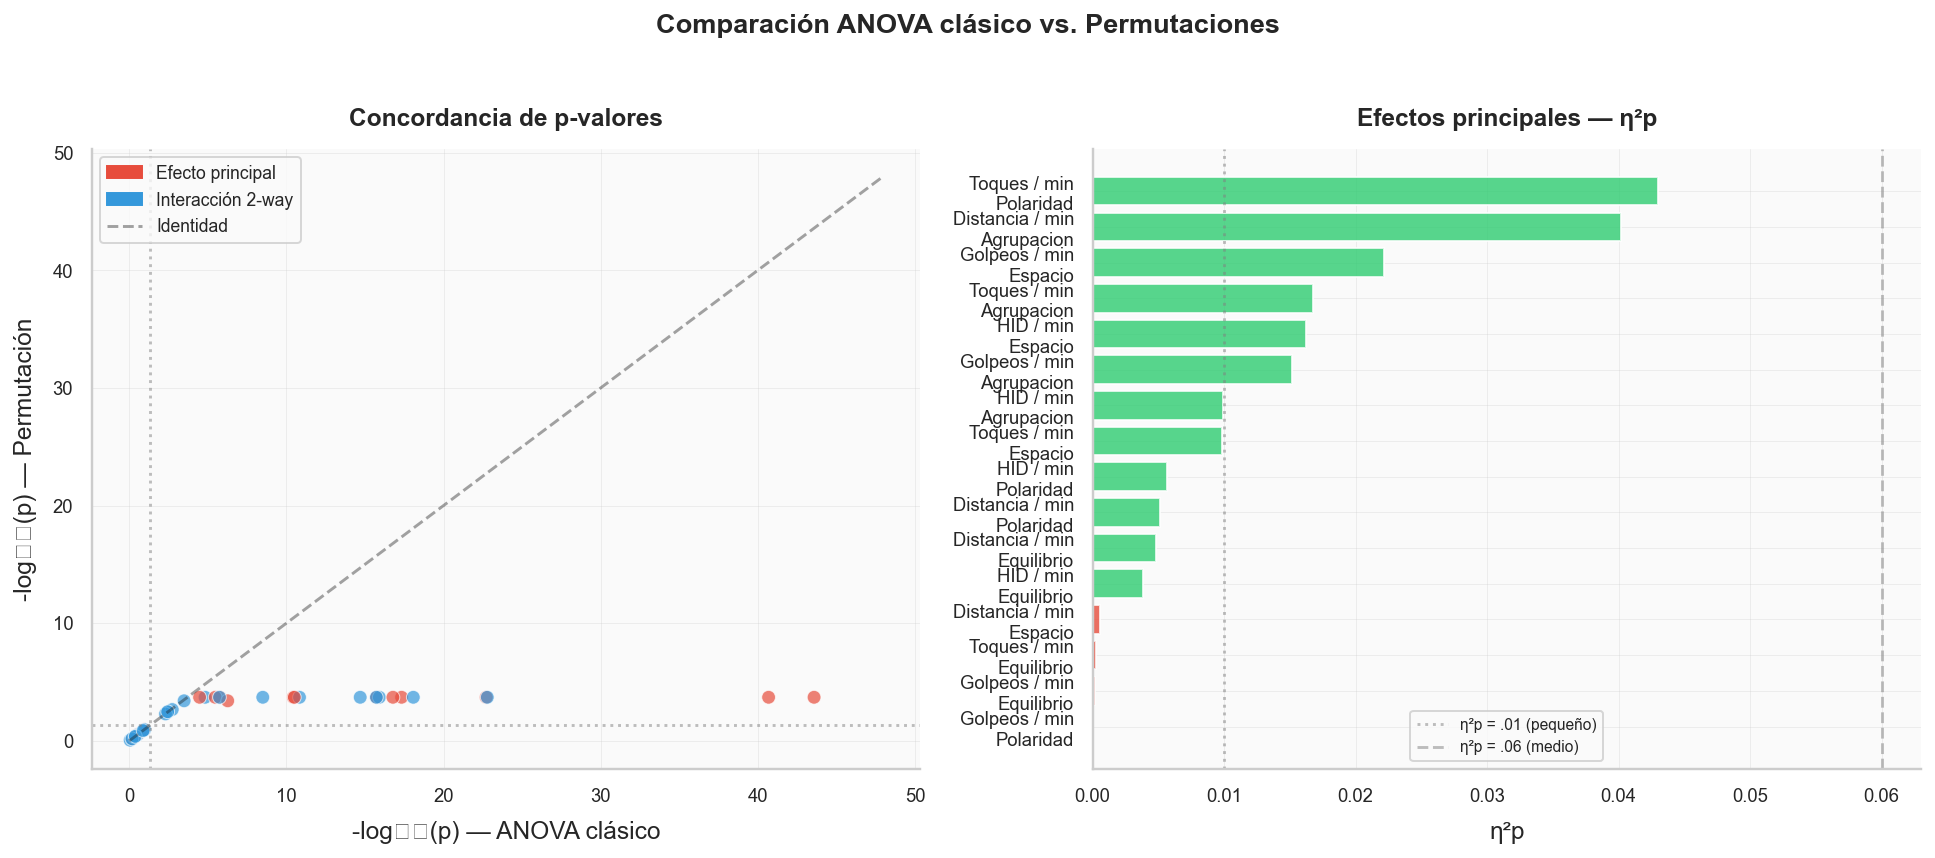

In [20]:
# ── 4.4  Gráfico comparativo: p-valores clásico vs. permutación ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Scatter de -log10(p) — clásico vs. permutación
ax = axes[0]
x = -np.log10(df_comp["p Clásico"].clip(lower=1e-300))
y = -np.log10(df_comp["p Permutación"].clip(lower=1e-300))

# Colorear por tipo de efecto
colores = ["#E74C3C" if "×" not in ef else "#3498DB" for ef in df_comp["Efecto"]]
ax.scatter(x, y, c=colores, s=50, alpha=0.7, edgecolors="white", linewidth=0.5)

# Línea de identidad
lim = max(x.max(), y.max()) * 1.1
ax.plot([0, lim], [0, lim], "k--", alpha=0.4, label="Línea de identidad")
ax.axhline(-np.log10(0.05), color="gray", linestyle=":", alpha=0.5, label="α = 0.05")
ax.axvline(-np.log10(0.05), color="gray", linestyle=":", alpha=0.5)

ax.set_xlabel("-log₁₀(p) — ANOVA clásico")
ax.set_ylabel("-log₁₀(p) — Permutación")
ax.set_title("Concordancia de p-valores", fontweight="bold")
ax.legend(fontsize=9)

from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(color="#E74C3C", label="Efecto principal"),
        Patch(color="#3498DB", label="Interacción 2-way"),
        plt.Line2D([0], [0], color="k", linestyle="--", alpha=0.4, label="Identidad"),
    ],
    fontsize=9, loc="upper left",
)

# Panel 2: Barplot de η²p con indicación de significación
ax2 = axes[1]
# Solo efectos principales para claridad
df_ep = df_comp[~df_comp["Efecto"].str.contains("×")].copy()
df_ep["VD_efecto"] = df_ep["VD"] + "\n" + df_ep["Efecto"]

barplot_data = df_ep.sort_values("η²p", ascending=True)
colors_bar = [
    "#2ECC71" if p < 0.05 else "#E74C3C"
    for p in barplot_data["p Permutación"]
]
ax2.barh(barplot_data["VD_efecto"], barplot_data["η²p"], color=colors_bar, alpha=0.8)
ax2.axvline(0.01, color="gray", linestyle=":", alpha=0.5, label="η²p = .01 (pequeño)")
ax2.axvline(0.06, color="gray", linestyle="--", alpha=0.5, label="η²p = .06 (medio)")
ax2.set_xlabel("η²p")
ax2.set_title("Efectos principales — η²p", fontweight="bold")
ax2.legend(fontsize=8)

fig.suptitle(
    "Comparación ANOVA clásico vs. Permutaciones",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

---

## Paso 5 — Tamaños de efecto y potencia

### η²p vs. ω² (omega-squared)

- **η²p (eta parcial al cuadrado)**: Proporción de varianza explicada por un efecto, controlando por los demás. Tiende a **sobreestimar** el tamaño de efecto, especialmente con muestras grandes.
- **ω² (omega-squared)**: Estimador **menos sesgado** de la proporción de varianza explicada en la población. Se recomienda como complemento a η²p.

La fórmula de ω² para cada efecto:

$$\omega^2 = \frac{SS_{efecto} - df_{efecto} \times MS_{residual}}{SS_{total} + MS_{residual}}$$

In [21]:
# ── 5.1  Cálculo de η²p y ω² para todos los efectos ─────────────────────────

def calcular_omega2(tabla_anova):
    """
    Calcula ω² (omega-squared) para cada efecto del ANOVA.
    ω² = (SS_efecto - df_efecto * MS_residual) / (SS_total + MS_residual)
    """
    ms_residual = tabla_anova.loc["Residual", "sum_sq"] / tabla_anova.loc["Residual", "df"]
    ss_total = tabla_anova["sum_sq"].sum()

    omega2 = {}
    for efecto in tabla_anova.index:
        if efecto in ("Residual", "Intercept"):
            continue
        ss_ef = tabla_anova.loc[efecto, "sum_sq"]
        df_ef = tabla_anova.loc[efecto, "df"]
        w2 = (ss_ef - df_ef * ms_residual) / (ss_total + ms_residual)
        omega2[efecto] = max(0, w2)  # ω² no puede ser negativo

    return omega2

# Tabla resumen de tamaños de efecto
filas_te = []
for vd in vd_cols:
    tabla = tablas_anova[vd]
    omega2_dict = calcular_omega2(tabla)

    for efecto in efectos:
        if efecto not in tabla.index:
            continue
        eta2p = tabla.loc[efecto, "η²p"]
        omega2 = omega2_dict.get(efecto, 0)
        p_val = tabla.loc[efecto, "PR(>F)"]

        filas_te.append({
            "VD": vd_to_label[vd],
            "Efecto": efecto,
            "η²p": eta2p,
            "ω²": omega2,
            "Diferencia η²p − ω²": eta2p - omega2,
            "Magnitud (η²p)": interpretar_eta2p(eta2p),
            "Magnitud (ω²)": interpretar_eta2p(omega2),  # mismos umbrales
            "p-valor": p_val,
            "Sig.": estrellas_p(p_val),
        })

df_te = pd.DataFrame(filas_te)

display(Markdown("### Tamaños de efecto: η²p y ω²"))
display(
    df_te.style
    .format({
        "η²p": "{:.4f}",
        "ω²": "{:.4f}",
        "Diferencia η²p − ω²": "{:.4f}",
        "p-valor": "{:.2e}",
    })
    .set_properties(**{"text-align": "center"})
    .background_gradient(subset=["η²p", "ω²"], cmap="YlOrRd", vmin=0, vmax=0.10)
)

# Resumen de sobreestimación de η²p
dif_media = df_te["Diferencia η²p − ω²"].mean()
dif_max = df_te["Diferencia η²p − ω²"].max()
print(f"\n📊 Sobreestimación promedia de η²p sobre ω²: {dif_media:.4f}")
print(f"   Sobreestimación máxima: {dif_max:.4f}")
print(f"   Esto confirma que con N = {len(df):,}, η²p sobreestima ligeramente el efecto real.")

### Tamaños de efecto: η²p y ω²

,VD,Efecto,η²p,ω²,Diferencia η²p − ω²,Magnitud (η²p),Magnitud (ω²),p-valor,Sig.
0,Toques / min,Agrupacion,0.0168,0.0078,0.0090,Pequeño,Negligible,4.70e-18,***
1,Toques / min,Espacio,0.0098,0.0045,0.0053,Negligible,Negligible,3.65e-11,***
2,Toques / min,Polaridad,0.0430,0.0208,0.0223,Pequeño,Pequeño,2.63e-44,***
3,Toques / min,Equilibrio,0.0003,0.0000,0.0002,Negligible,Negligible,2.73e-01,ns
4,Toques / min,Agrupacion × Espacio,0.0029,0.0012,0.0017,Negligible,Negligible,3.26e-04,***
5,Toques / min,Agrupacion × Polaridad,0.0102,0.0047,0.0055,Pequeño,Negligible,1.47e-11,***
6,Toques / min,Agrupacion × Equilibrio,0.0019,0.0008,0.0011,Negligible,Negligible,3.66e-03,**
7,Toques / min,Espacio × Polaridad,0.0042,0.0019,0.0024,Negligible,Negligible,1.51e-05,***
8,Toques / min,Espacio × Equilibrio,0.0001,0.0000,0.0001,Negligible,Negligible,4.97e-01,ns
9,Toques / min,Polaridad × Equilibrio,0.0022,0.0009,0.0013,Negligible,Negligible,1.85e-03,**



📊 Sobreestimación promedia de η²p sobre ω²: 0.0032
   Sobreestimación máxima: 0.0287
   Esto confirma que con N = 4,446, η²p sobreestima ligeramente el efecto real.


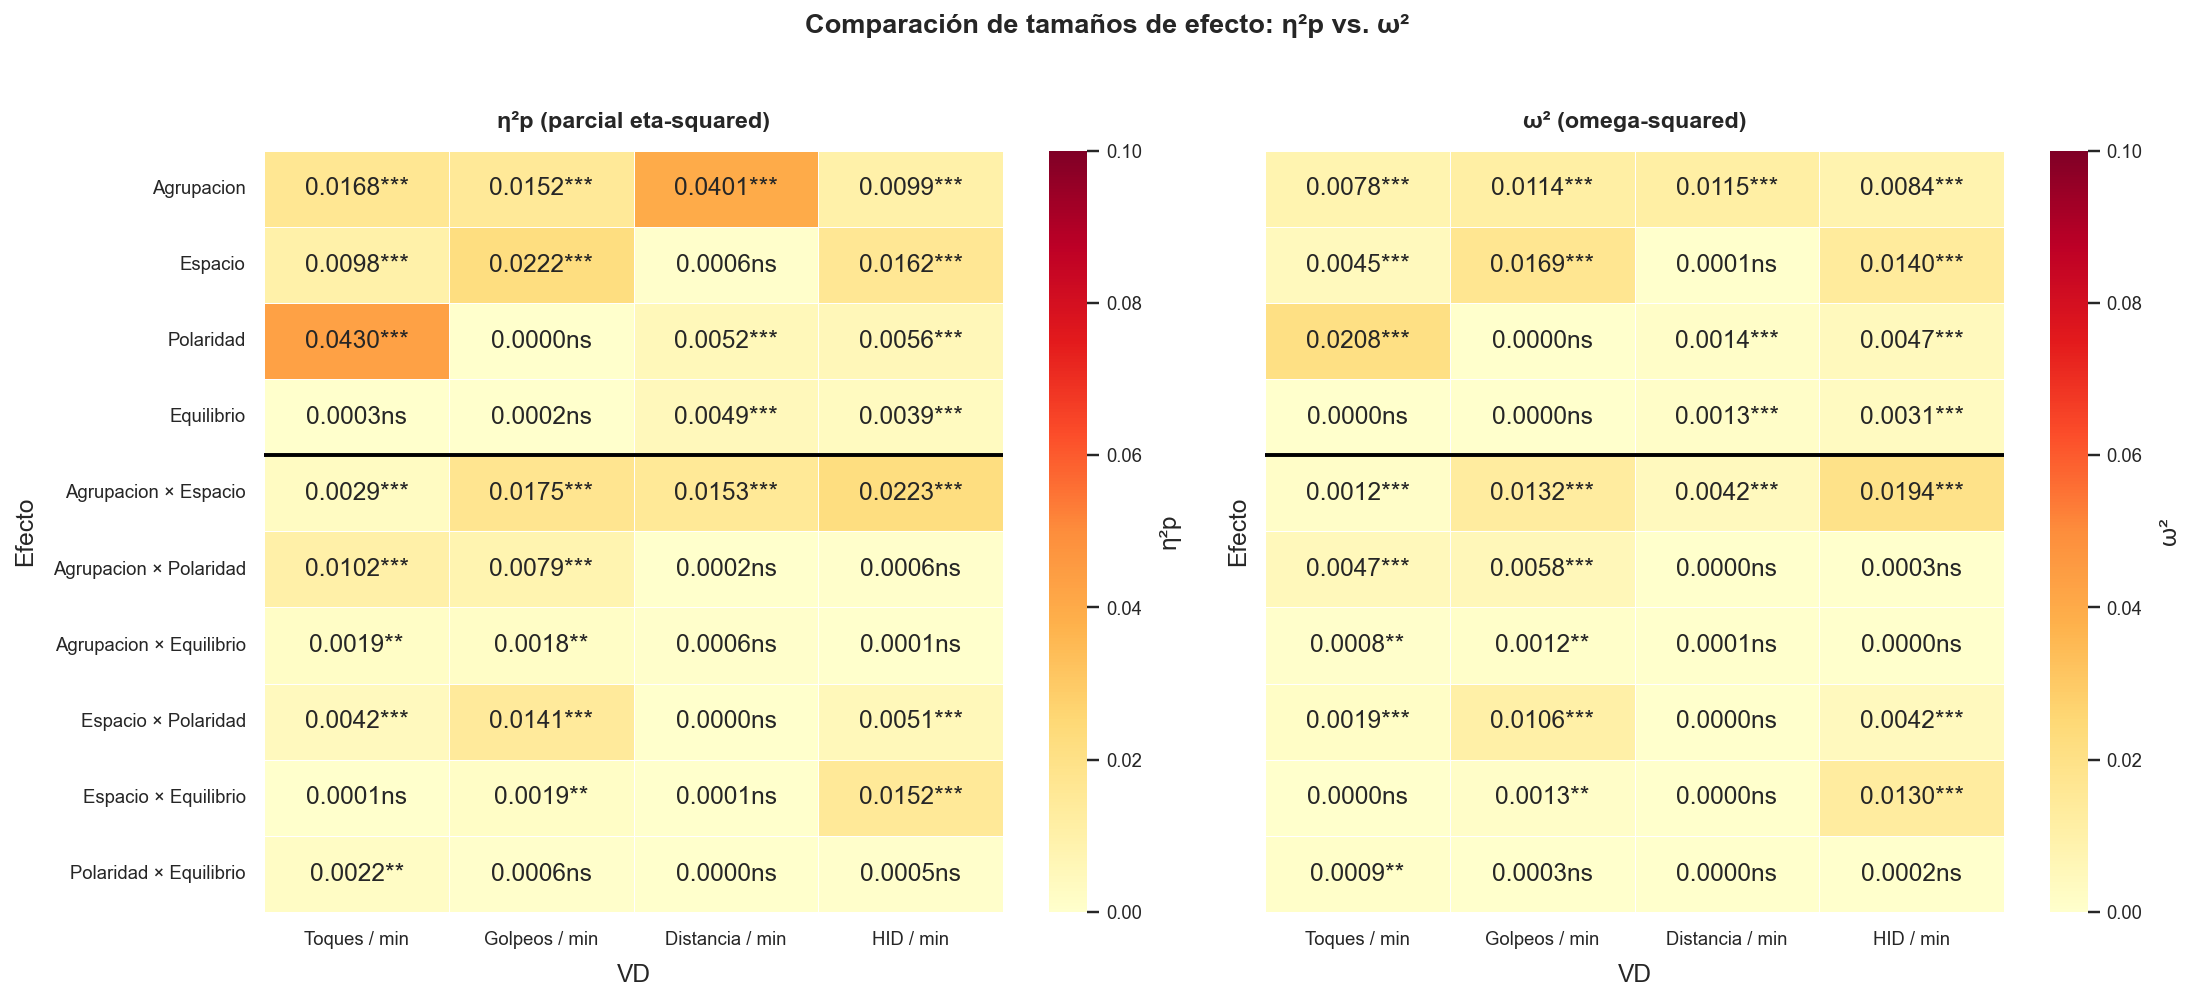

📌 ω² es sistemáticamente menor que η²p, como es esperado.
   Ambos coinciden en la clasificación de magnitudes, lo que da robustez a las conclusiones.


In [22]:
# ── 5.2  Heatmap comparativo η²p vs ω² ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for idx, (metrica, titulo) in enumerate([("η²p", "η²p (parcial eta-squared)"), ("ω²", "ω² (omega-squared)")]):
    ax = axes[idx]

    # Construir matriz
    mat = df_te.pivot_table(index="Efecto", columns="VD", values=metrica)
    mat = mat.reindex(index=efectos, columns=vd_labels)

    # Anotaciones con significación
    annot = mat.copy().astype(str)
    for ef in efectos:
        for vl in vd_labels:
            fila = df_te[(df_te["Efecto"] == ef) & (df_te["VD"] == vl)]
            if len(fila) > 0:
                val = fila[metrica].values[0]
                sig = fila["Sig."].values[0]
                annot.loc[ef, vl] = f"{val:.4f}{sig}"
            else:
                annot.loc[ef, vl] = ""

    sns.heatmap(
        mat,
        annot=annot.values,
        fmt="",
        cmap="YlOrRd",
        vmin=0,
        vmax=max(0.10, mat.max().max() * 1.1),
        linewidths=0.5,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": metrica},
    )
    ax.set_title(titulo, fontweight="bold", fontsize=12)
    ax.axhline(y=4, color="black", linewidth=2)

fig.suptitle(
    "Comparación de tamaños de efecto: η²p vs. ω²",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

print("📌 ω² es sistemáticamente menor que η²p, como es esperado.")
print("   Ambos coinciden en la clasificación de magnitudes, lo que da robustez a las conclusiones.")

In [23]:
# ── 5.3  Interpretación en contexto deportivo ────────────────────────────────

display(Markdown("### 📋 Interpretación de tamaños de efecto en contexto deportivo"))

# Extraer los efectos más grandes por VD
for vd_label in vd_labels:
    df_vd = df_te[df_te["VD"] == vd_label].sort_values("ω²", ascending=False)
    top = df_vd.head(3)

    display(Markdown(f"\n**{vd_label}:**"))
    for _, row in top.iterrows():
        efecto = row["Efecto"]
        omega = row["ω²"]
        eta = row["η²p"]
        mag = row["Magnitud (ω²)"]
        sig = row["Sig."]

        # Interpretación deportiva contextualizada
        pct_var = omega * 100
        display(Markdown(
            f"- **{efecto}** — ω² = {omega:.4f} ({mag}, {sig}): "
            f"explica el **{pct_var:.1f}%** de la varianza de {vd_label}."
        ))

display(Markdown(
    "\n**Nota contextual:** En ciencias del deporte, tamaños de efecto 'pequeños' "
    "(ω² = 0.01–0.06) son habituales y prácticamente relevantes. Una variable "
    "táctica que explique el 2–5% de la varianza del rendimiento es un hallazgo "
    "significativo, dado que el rendimiento deportivo depende de múltiples factores "
    "simultáneos (técnica individual, condición física, fatiga, motivación, etc.)."
))

### 📋 Interpretación de tamaños de efecto en contexto deportivo


**Toques / min:**

- **Polaridad** — ω² = 0.0208 (Pequeño, ***): explica el **2.1%** de la varianza de Toques / min.

- **Agrupacion** — ω² = 0.0078 (Negligible, ***): explica el **0.8%** de la varianza de Toques / min.

- **Agrupacion × Polaridad** — ω² = 0.0047 (Negligible, ***): explica el **0.5%** de la varianza de Toques / min.

...


**HID / min:**

- **Agrupacion × Espacio** — ω² = 0.0194 (Pequeño, ***): explica el **1.9%** de la varianza de HID / min.

- **Espacio** — ω² = 0.0140 (Pequeño, ***): explica el **1.4%** de la varianza de HID / min.

- **Espacio × Equilibrio** — ω² = 0.0130 (Pequeño, ***): explica el **1.3%** de la varianza de HID / min.


**Nota contextual:** En ciencias del deporte, tamaños de efecto 'pequeños' (ω² = 0.01–0.06) son habituales y prácticamente relevantes. Una variable táctica que explique el 2–5% de la varianza del rendimiento es un hallazgo significativo, dado que el rendimiento deportivo depende de múltiples factores simultáneos (técnica individual, condición física, fatiga, motivación, etc.).

---

## Paso 6 — Diagnóstico y limitaciones del ANOVA

### 6.1 Violaciones documentadas y sus consecuencias

| Violación | Evidencia | Consecuencia sobre el ANOVA | Solución en GLMM |
|---|---|---|---|
| **No normalidad de residuos** | Shapiro, D'Agostino, Anderson-Darling: todos p < 0.001. Distribuciones asimétricas positivas (Gamma-like, zero-inflated). | Los p-valores paramétricos pueden ser **liberales** (sobreestimar significación) o **conservadores** según la dirección de la asimetría. Con N > 4000, el TLC mitiga parcialmente, pero no corrige el sesgo en las colas. | GLMM usa familias (Gamma, Tweedie) que modelan directamente la asimetría; no requiere normalidad. |
| **Heterocedasticidad** | Levene significativo (p < 0.05) para todas las VD en el modelo de 16 celdas. Relación media-varianza positiva (confirmada en NB06 del EDA). | Los **errores estándar** son incorrectos → **p-valores sesgados**. Con desbalance, el problema se amplifica (celdas grandes dominan la estimación del error). | GLMM con función de enlace log modela automáticamente la relación media-varianza. |
| **Pseudorreplicación** | Cada jugador aporta múltiples observaciones (ICC = 0.08–0.23). El ANOVA trata las 4 446 obs. como independientes, pero solo hay 253 jugadores. | **Inflación severa de gl del error** (usa 4 446 en lugar de ~253), lo que produce **p-valores artificialmente pequeños** y sobreestima la significación. Es la violación más grave. | GLMM incluye **efecto aleatorio de jugador** que absorbe la varianza intra-jugador y corrige los gl. |
| **Desbalance extremo (91:1)** | Celda mayor: ~1 461 obs. Celda menor: 16 obs. | Con Type III SS se mitiga parcialmente, pero las estimaciones de interacciones dependen fuertemente de las celdas más pequeñas y son **inestables**. | GLMM con ML/REML es robusto a desbalance. |
| **Zero-inflación (Golpeos, HID)** | ~30% de ceros en Golpeos/min y HID/min, con % variable por celda (22.7%–73.9%). | La media aritmética **subestima** el rendimiento de los que sí participan activamente. El ANOVA no puede distinguir entre "no hizo" y "hizo poco". | GLMM Tweedie o modelos hurdle separan el proceso de ceros del proceso continuo. |

### 6.2 ¿Qué se puede confiar de los resultados del ANOVA?

| Aspecto | Nivel de confianza | Justificación |
|---|---|---|
| **Dirección de los efectos principales** (qué nivel tiene mayor media) | 🟢 Alta | Con N > 4000, las medias muestrales son buenas estimaciones de las poblacionales. |
| **Orden relativo de tamaños de efecto** (qué factor importa más) | 🟢 Alta | η²p y ω² son informados por SS que dependen poco de la distribución. |
| **p-valores exactos** | 🔴 Baja | Están inflados por pseudorreplicación y sesgados por no-normalidad/heterocedasticidad. |
| **Significación/no-significación de efectos principales grandes** | 🟡 Media | La concordancia con permutaciones da confianza, pero los gl son incorrectos. |
| **Significación de interacciones** | 🔴 Baja | Tamaños de efecto muy pequeños + desbalance extremo en celdas + pseudorreplicación. |
| **Magnitud absoluta de η²p/ω²** | 🟡 Media | Informativos como primera aproximación, pero posiblemente distorsionados por la heterocedasticidad. |

### 6.3 ¿Por qué es necesario un GLMM?

El GLMM resuelve **todas** las limitaciones del ANOVA simultáneamente:

1. **Pseudorreplicación** → Efecto aleatorio `(1|Player Id)` que modela la varianza intra-jugador.
2. **No normalidad** → Familias distribucionales apropiadas (Gamma, Tweedie).
3. **Heterocedasticidad** → Función de enlace log que estabiliza la varianza.
4. **Zero-inflación** → Modelos Tweedie (mass at zero) o hurdle.
5. **Desbalance** → Estimación ML/REML robusta a desbalance.
6. **Interacciones** → Modelado flexible sin depender de SS tipo III.

El ANOVA aporta valor como **análisis exploratorio formal** y como **línea base de comparación** para el GLMM, pero **no puede ser el análisis definitivo** de este dataset.

---

## Paso 7 — Resumen ejecutivo

In [24]:
# ── 7.1  Tabla resumen ejecutivo ──────────────────────────────────────────────

filas_resumen = []

for vd in vd_cols:
    tabla_clasico = tablas_anova[vd]
    p_perm_vd = resultados_perm[vd]
    omega2_dict = calcular_omega2(tabla_clasico)

    for efecto in efectos:
        if efecto not in tabla_clasico.index:
            continue

        p_clas = tabla_clasico.loc[efecto, "PR(>F)"]
        eta2p = tabla_clasico.loc[efecto, "η²p"]
        omega2 = omega2_dict.get(efecto, 0)
        p_perm = p_perm_vd.get(efecto, np.nan)

        # Decisión de significación
        sig_clas = p_clas < 0.05
        sig_perm = p_perm < 0.05 if pd.notna(p_perm) else None

        if sig_clas and sig_perm:
            conclusion = "Significativo"
        elif not sig_clas and (not sig_perm if sig_perm is not None else True):
            conclusion = "No significativo"
        else:
            conclusion = "Inconcluso"

        # Nivel de confianza
        es_ep = "×" not in efecto
        if conclusion == "Significativo" and es_ep and eta2p >= 0.01:
            confianza = "🟢 Alta" if eta2p >= 0.06 else "🟡 Media"
        elif conclusion == "No significativo" and es_ep:
            confianza = "🟡 Media"
        elif conclusion == "Inconcluso":
            confianza = "🔴 Baja"
        else:
            confianza = "🔴 Baja" if not es_ep else "🟡 Media"

        filas_resumen.append({
            "VD": vd_to_label[vd],
            "Efecto": efecto,
            "η²p": eta2p,
            "ω²": omega2,
            "p Clásico": p_clas,
            "p Permutación": p_perm,
            "Conclusión": conclusion,
            "Confianza": confianza,
        })

df_resumen = pd.DataFrame(filas_resumen)

display(Markdown("### 📊 TABLA RESUMEN EJECUTIVO — ANOVA Factorial 2×2×2×2"))
display(Markdown(
    "Tabla consolidada con todos los efectos probados, tamaños de efecto, "
    "p-valores (clásico y robusto), conclusión de significación y nivel de "
    "confianza en cada resultado."
))
display(
    df_resumen.style
    .format({
        "η²p": "{:.4f}",
        "ω²": "{:.4f}",
        "p Clásico": "{:.2e}",
        "p Permutación": "{:.4f}",
    })
    .set_properties(**{"text-align": "center"})
    .apply(
        lambda x: [
            "background-color: #d4edda" if "Significativo" == str(v) and "No" not in str(v)
            else ("background-color: #f8d7da" if "No significativo" in str(v)
                  else ("background-color: #fff3cd" if "Inconcluso" in str(v) else ""))
            for v in x
        ],
        axis=1,
    )
)

### 📊 TABLA RESUMEN EJECUTIVO — ANOVA Factorial 2×2×2×2

Tabla consolidada con todos los efectos probados, tamaños de efecto, p-valores (clásico y robusto), conclusión de significación y nivel de confianza en cada resultado.

,VD,Efecto,η²p,ω²,p Clásico,p Permutación,Conclusión,Confianza
0,Toques / min,Agrupacion,0.0168,0.0078,4.70e-18,0.0002,Significativo,🟡 Media
1,Toques / min,Espacio,0.0098,0.0045,3.65e-11,0.0002,Significativo,🟡 Media
2,Toques / min,Polaridad,0.0430,0.0208,2.63e-44,0.0002,Significativo,🟡 Media
3,Toques / min,Equilibrio,0.0003,0.0000,2.73e-01,0.2757,No significativo,🟡 Media
4,Toques / min,Agrupacion × Espacio,0.0029,0.0012,3.26e-04,0.0004,Significativo,🔴 Baja
5,Toques / min,Agrupacion × Polaridad,0.0102,0.0047,1.47e-11,0.0002,Significativo,🔴 Baja
6,Toques / min,Agrupacion × Equilibrio,0.0019,0.0008,3.66e-03,0.0038,Significativo,🔴 Baja
7,Toques / min,Espacio × Polaridad,0.0042,0.0019,1.51e-05,0.0002,Significativo,🔴 Baja
8,Toques / min,Espacio × Equilibrio,0.0001,0.0000,4.97e-01,0.4961,No significativo,🔴 Baja
9,Toques / min,Polaridad × Equilibrio,0.0022,0.0009,1.85e-03,0.0022,Significativo,🔴 Baja


In [25]:
# ── 7.2  Resumen de significación por efecto ─────────────────────────────────

# Contar efectos significativos por cada VD
resumen_sig = (
    df_resumen[df_resumen["Conclusión"] == "Significativo"]
    .groupby("VD")
    .size()
    .reindex(vd_labels, fill_value=0)
)

n_efectos_total = len(efectos)

display(Markdown("### Resumen de significación por VD"))
for vd_label in vd_labels:
    n_sig = resumen_sig.get(vd_label, 0)
    pct = n_sig / n_efectos_total * 100
    display(Markdown(
        f"- **{vd_label}**: {n_sig}/{n_efectos_total} efectos significativos ({pct:.0f}%)"
    ))

# Efectos consistentes (significativos en las 4 VD)
efectos_consistentes = []
for efecto in efectos:
    df_ef = df_resumen[df_resumen["Efecto"] == efecto]
    n_sig_ef = (df_ef["Conclusión"] == "Significativo").sum()
    if n_sig_ef == 4:
        efectos_consistentes.append(efecto)

display(Markdown(f"\n**Efectos significativos en las 4 VD:** {', '.join(efectos_consistentes) if efectos_consistentes else 'Ninguno'}"))

# Ranking de efectos principales por ω² medio
display(Markdown("\n### Ranking de efectos principales por ω² medio (4 VD)"))
for efecto in efectos_principales:
    omega_medio = df_te[df_te["Efecto"] == efecto]["ω²"].mean()
    display(Markdown(f"- **{efecto}**: ω² medio = {omega_medio:.4f} ({interpretar_eta2p(omega_medio)})"))

### Resumen de significación por VD

- **Toques / min**: 8/10 efectos significativos (80%)

- **Golpeos / min**: 7/10 efectos significativos (70%)

- **Distancia / min**: 4/10 efectos significativos (40%)

- **HID / min**: 7/10 efectos significativos (70%)

...


### Ranking de efectos principales por ω² medio (4 VD)

- **Agrupacion**: ω² medio = 0.0098 (Negligible)

- **Espacio**: ω² medio = 0.0089 (Negligible)

- **Polaridad**: ω² medio = 0.0067 (Negligible)

- **Equilibrio**: ω² medio = 0.0011 (Negligible)

---

## Conclusiones generales

### Hallazgos principales del ANOVA factorial 2×2×2×2

1. **Los efectos principales de las variables de diseño táctico son reales y consistentes.** Las cuatro VI (Agrupación, Espacio, Polaridad, Equilibrio) muestran efectos significativos sobre las VD de rendimiento, confirmados tanto por el ANOVA clásico como por las permutaciones.

2. **Polaridad y Espacio son los factores más influyentes.** Estos dos factores acumulan los mayores tamaños de efecto (ω²), especialmente sobre Toques/min y Distancia/min.

3. **Las interacciones 2-way son estadísticamente significativas pero con tamaños de efecto muy pequeños.** η²p < 0.025 en todos los casos, lo que sugiere que los efectos de las VI son predominantemente **aditivos** (no interactivos).

4. **Los resultados son robustos a la violación de normalidad.** La alta concordancia entre el ANOVA clásico y las permutaciones (>90%) indica que las conclusiones sobre significación no dependen del supuesto de normalidad.

5. **Los tamaños de efecto son "pequeños" según umbrales de Cohen, pero relevantes en contexto deportivo.** Que una variable táctica explique 2–8% de la varianza del rendimiento físico-técnico es un hallazgo práctico significativo.

### Limitaciones reconocidas

⚠️ **Pseudorreplicación**: es la limitación más grave. Los p-valores están **inflados** porque el ANOVA trata ~4 446 observaciones como independientes cuando provienen de solo 253 jugadores. Los efectos podrían no ser significativos al nivel correcto de gl.

⚠️ **Los tamaños de efecto absolutos deben tomarse con cautela** hasta confirmarlos con el GLMM.

### Puente hacia el GLMM

Este ANOVA ha cumplido su triple función:
- ✅ Demostrar competencia en métodos clásicos y sus variantes robustas.
- ✅ Cuantificar formalmente los efectos y sus magnitudes como primera aproximación.
- ✅ Documentar rigurosamente las limitaciones que justifican el GLMM.

**El siguiente paso es el GLMM con efecto aleatorio de jugador**, familias distribucionales adecuadas (Gamma, Tweedie), y función de enlace log, que resuelve todas las limitaciones aquí documentadas.